## 학습목표

1. **평균, 중앙값, 표준편차** 등 데이터 요약 수치의 수학적 의미와 계산 원리를 이해함
2. **Matplotlib**과 **Seaborn**을 활용하여 다양한 시각화 기법을 구현함
3. **히스토그램, 상자그림, 산점도**를 해석하고 제조 현장에 적용함
4. 실제 **제조 데이터**를 활용한 탐색적 데이터 분석(EDA)을 수행함

### 실습 환경 설정(한글 그래픽 안깨지게)

In [24]:
# 필수 라이브러리 설치 및 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # macOS
plt.rcParams['axes.unicode_minus'] = False

# 출력 형식 설정
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


본 실습에서는 **UCI Machine Learning Repository**에서 제공하는 **Steel Industry Energy Consumption Dataset**을 활용함. 이 데이터셋은 한국 광양의 **대우제철(DAEWOO Steel Co. Ltd)** 에서 수집된 실제 제조 현장 데이터임.

**데이터셋 개요:**
- **출처**: UCI Machine Learning Repository (ID: 851)
- **수집 기간**: 2018년
- **수집 장소**: 대한민국 광양시 대우제철
- **샘플 수**: 35,040개 (15분 간격 측정)
- **특성 수**: 10개 변수

**변수 설명:**

| 변수명 | 설명 | 단위 | 유형 |
|--------|------|------|------|
| `date` | 측정 일시 | - | 시간 |
| `Usage_kWh` | 산업용 에너지 소비량 | kWh | 연속형 |
| `Lagging_Current_Reactive.Power_kVarh` | 지상 무효전력 | kVarh | 연속형 |
| `Leading_Current_Reactive.Power_kVarh` | 진상 무효전력 | kVarh | 연속형 |
| `CO2(tCO2)` | 이산화탄소 배출량 | tCO2 | 연속형 |
| `Lagging_Current_Power_Factor` | 지상 역률 | % | 연속형 |
| `Leading_Current_Power_Factor` | 진상 역률 | % | 연속형 |
| `NSM` | 자정부터 경과 시간 | 초 | 연속형 |
| `WeekStatus` | 주중/주말 구분 | - | 범주형 |
| `Day_of_week` | 요일 | - | 범주형 |
| `Load_Type` | 부하 유형 | - | 범주형 |


```python
# 데이터 로딩 방법 1: UCI 저장소에서 직접 다운로드
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# 데이터셋 가져오기
steel_energy = fetch_ucirepo(id=851)

# 데이터프레임으로 변환
X = steel_energy.data.features
y = steel_energy.data.targets

# 전체 데이터프레임 생성
df = pd.concat([X, y], axis=1)

# 컬럼명 간소화
df.columns = ['Usage_kWh', 'Lagging_Reactive_Power', 'Leading_Reactive_Power', 
              'CO2', 'Lagging_Power_Factor', 'Leading_Power_Factor',
              'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

print(f"데이터셋 크기: {df.shape}")
print(f"총 샘플 수: {len(df):,}개")
print(f"변수 수: {df.shape[1]}개")
```

```python
# 데이터 로딩 방법 2: Kaggle에서 다운로드한 CSV 파일 사용
URL: https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption

df = pd.read_csv('Steel_industry_data.csv')
df.columns = ['date', 'Usage_kWh', 'Lagging_Reactive_Power', 'Leading_Reactive_Power', 
              'CO2', 'Lagging_Power_Factor', 'Leading_Power_Factor',
              'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']
```

In [8]:
# 실제로는, 자료를 받아와서 csv로 로딩해볼것.

df = pd.read_csv('Steel_industry_data.csv')
df.columns = ['date', 'Usage_kWh', 'Lagging_Reactive_Power', 'Leading_Reactive_Power', 
              'CO2', 'Lagging_Power_Factor', 'Leading_Power_Factor',
              'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

In [9]:
#데이터 기본 탐색

# 데이터 기본 정보 확인
print("=" * 60)
print("데이터 기본 정보")
print("=" * 60)
print(f"\n데이터 크기: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

print("데이터 타입:")
print(df.dtypes)
print("\n" + "=" * 60)

데이터 기본 정보

데이터 크기: 35,040 rows × 11 columns

데이터 타입:
date                       object
Usage_kWh                 float64
Lagging_Reactive_Power    float64
Leading_Reactive_Power    float64
CO2                       float64
Lagging_Power_Factor      float64
Leading_Power_Factor      float64
NSM                         int64
WeekStatus                 object
Day_of_week                object
Load_Type                  object
dtype: object



In [10]:
# 처음 10행 확인
print("데이터 미리보기 (상위 10행):")
df.head(10)


데이터 미리보기 (상위 10행):


,date,Usage_kWh,Lagging_Reactive_Power,Leading_Reactive_Power,CO2,Lagging_Power_Factor,Leading_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.1700,2.9500,0.0000,0.0000,73.2100,100.0000,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.0000,4.4600,0.0000,0.0000,66.7700,100.0000,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.2400,3.2800,0.0000,0.0000,70.2800,100.0000,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.3100,3.5600,0.0000,0.0000,68.0900,100.0000,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.8200,4.5000,0.0000,0.0000,64.7200,100.0000,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.2800,3.5600,0.0000,0.0000,67.7600,100.0000,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.6000,4.1400,0.0000,0.0000,65.6200,100.0000,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.6000,4.2800,0.0000,0.0000,64.3700,100.0000,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.2800,3.6400,0.0000,0.0000,66.9400,100.0000,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.7800,4.7200,0.0000,0.0000,62.5100,100.0000,9000,Weekday,Monday,Light_Load


In [11]:
# 결측치 확인
print("결측치 현황:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '비율(%)': missing_pct})
print(missing_df)

결측치 현황:
                        결측치 수  비율(%)
date                        0 0.0000
Usage_kWh                   0 0.0000
Lagging_Reactive_Power      0 0.0000
Leading_Reactive_Power      0 0.0000
CO2                         0 0.0000
Lagging_Power_Factor        0 0.0000
Leading_Power_Factor        0 0.0000
NSM                         0 0.0000
WeekStatus                  0 0.0000
Day_of_week                 0 0.0000
Load_Type                   0 0.0000


# 대표값(Central Tendency)의 이해

## 대표값이란?

**대표값(Measure of Central Tendency)** 은 데이터의 **중심 위치**를 나타내는 단일 수치임. 수천, 수만 개의 데이터 포인트를 하나의 숫자로 요약하여 데이터의 전반적인 특성을 파악할 수 있게 함.

**대표값이 필요한 이유:**
- 대량의 데이터를 간결하게 요약
- 서로 다른 데이터셋 간 비교 가능
- 의사결정의 기준점 제공
- 이상치 탐지의 기준 설정

## 산술평균(Arithmetic Mean)

### 정의 및 수식

**산술평균(Arithmetic Mean)** 은 모든 관측값의 합을 관측값의 개수로 나눈 값임.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + x_3 + \cdots + x_n}{n}$$

**기호 설명:**
- $\bar{x}$ (x-bar): 표본평균
- $n$: 표본 크기 (데이터 개수)
- $x_i$: i번째 관측값
- $\sum$: 합계 기호 (sigma)

> **참고**: 모집단 평균은 $\mu$ (mu)로 표기함: $\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$

### 수식 전개 예시

**예제 데이터**: 생산라인 온도 측정값 $x = \{85, 86, 84, 87, 85, 86, 84, 85\}$

$$\bar{x} = \frac{85 + 86 + 84 + 87 + 85 + 86 + 84 + 85}{8} = \frac{682}{8} = 85.25°C$$


In [12]:
# 예제 데이터로 평균 계산 과정 확인
temps = np.array([85, 86, 84, 87, 85, 86, 84, 85])

# 단계별 계산
total = np.sum(temps)
n = len(temps)
mean_manual = total / n

print("산술평균 계산 과정")
print("=" * 50)
print(f"데이터: {temps}")
print(f"합계 (Σxᵢ): {total}")
print(f"개수 (n): {n}")
print(f"평균 (x̄ = Σxᵢ/n): {total}/{n} = {mean_manual:.2f}°C")
print(f"\nNumPy 검증: np.mean(temps) = {np.mean(temps):.2f}°C")

산술평균 계산 과정
데이터: [85 86 84 87 85 86 84 85]
합계 (Σxᵢ): 682
개수 (n): 8
평균 (x̄ = Σxᵢ/n): 682/8 = 85.25°C

NumPy 검증: np.mean(temps) = 85.25°C


In [13]:
# Steel Industry 데이터에서 에너지 소비량 평균 계산
usage = df['Usage_kWh']

# 단계별 계산
total_usage = usage.sum()
n_samples = len(usage)
mean_usage = total_usage / n_samples

print("에너지 소비량(Usage_kWh) 산술평균 계산")
print("=" * 60)
print(f"총 합계: {total_usage:,.2f} kWh")
print(f"샘플 수: {n_samples:,}개")
print(f"산술평균: {mean_usage:.4f} kWh")
print(f"\n검증 (Pandas): {usage.mean():.4f} kWh")
print(f"검증 (NumPy): {np.mean(usage):.4f} kWh")

에너지 소비량(Usage_kWh) 산술평균 계산
총 합계: 959,636.71 kWh
샘플 수: 35,040개
산술평균: 27.3869 kWh

검증 (Pandas): 27.3869 kWh
검증 (NumPy): 27.3869 kWh


### 평균의 수학적 특성

#### **특성 1: 편차의 합은 0**

$$\sum_{i=1}^{n}(x_i - \bar{x}) = 0$$

평균을 기준으로 한 편차(deviation)의 합은 항상 0임. 이는 평균이 데이터의 "무게중심"임을 의미함.

In [14]:
# 편차의 합 = 0 검증
deviations = usage - usage.mean()
sum_of_deviations = deviations.sum()

print("편차의 합 검증")
print("=" * 50)
print(f"평균: {usage.mean():.4f}")
print(f"편차의 합: {sum_of_deviations:.10f}")
print(f"→ 부동소수점 오차 범위 내에서 0임을 확인")

편차의 합 검증
평균: 27.3869
편차의 합: -0.0000000001
→ 부동소수점 오차 범위 내에서 0임을 확인


#### **특성 2: 편차제곱합의 최소화**

평균은 모든 데이터 포인트로부터의 **편차제곱합(Sum of Squared Deviations)** 을 최소화하는 값임.

$$\bar{x} = \arg\min_{c} \sum_{i=1}^{n}(x_i - c)^2$$

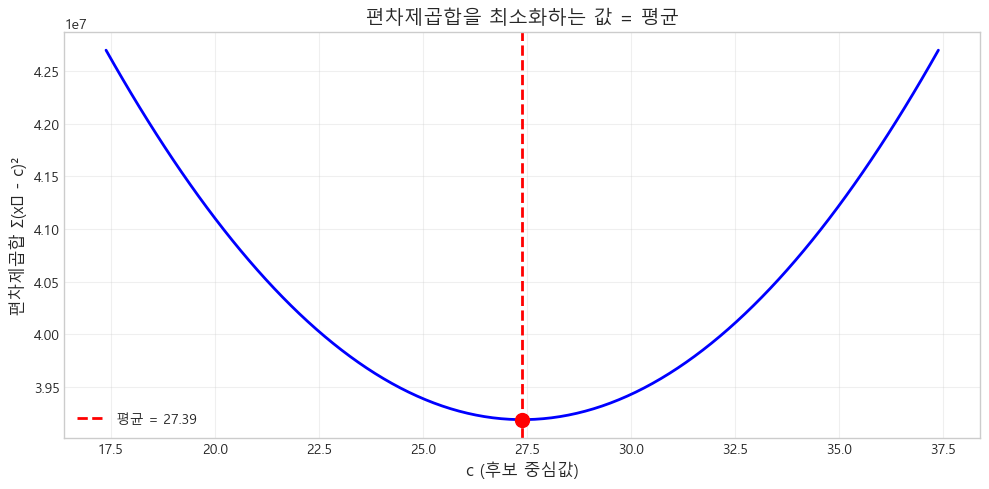

평균(27.39)에서 편차제곱합이 최소임을 확인


In [25]:
# 편차제곱합 최소화 시각화
test_values = np.linspace(usage.mean() - 10, usage.mean() + 10, 100)
ssd_values = [(((usage - c)**2).sum()) for c in test_values]

plt.figure(figsize=(10, 5))
plt.plot(test_values, ssd_values, 'b-', linewidth=2)
plt.axvline(usage.mean(), color='red', linestyle='--', linewidth=2, label=f'평균 = {usage.mean():.2f}')
plt.scatter([usage.mean()], [min(ssd_values)], color='red', s=100, zorder=5)
plt.xlabel('c (후보 중심값)', fontsize=12)
plt.ylabel('편차제곱합 Σ(xᵢ - c)²', fontsize=12)
plt.title('편차제곱합을 최소화하는 값 = 평균', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"평균({usage.mean():.2f})에서 편차제곱합이 최소임을 확인")

#### 이상치(Outlier)에 대한 민감성

**평균의 가장 큰 약점** 은 **이상치에 민감** 하다는 것임. 극단적인 값 하나가 전체 평균을 크게 왜곡할 수 있음.

In [22]:
# 이상치 영향 시뮬레이션
normal_data = np.random.normal(85, 2, 99)  # 정상 데이터 99개
outlier = 200  # 이상치 1개

# 이상치 없는 경우
mean_without_outlier = normal_data.mean()

# 이상치 포함
data_with_outlier = np.append(normal_data, outlier)
mean_with_outlier = data_with_outlier.mean()

print("이상치가 평균에 미치는 영향")
print("=" * 50)
print(f"정상 데이터 평균 (n=99): {mean_without_outlier:.2f}°C")
print(f"이상치(200°C) 포함 평균 (n=100): {mean_with_outlier:.2f}°C")
print(f"차이: {mean_with_outlier - mean_without_outlier:.2f}°C (약 {(mean_with_outlier - mean_without_outlier)/mean_without_outlier*100:.1f}% 증가)")

이상치가 평균에 미치는 영향
정상 데이터 평균 (n=99): 84.86°C
이상치(200°C) 포함 평균 (n=100): 86.01°C
차이: 1.15°C (약 1.4% 증가)


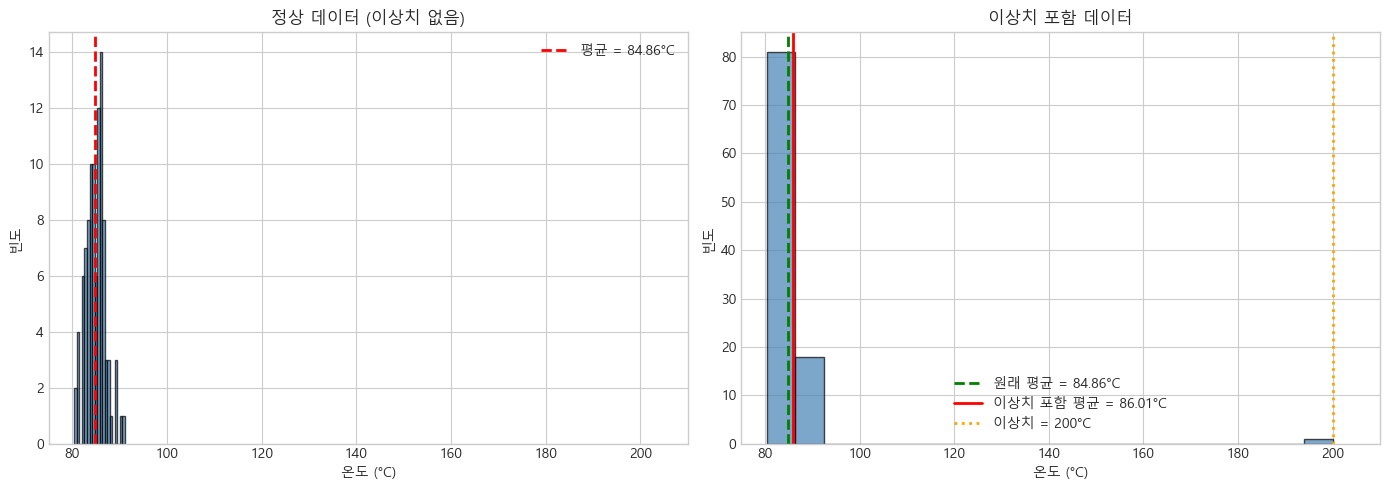

In [26]:
# 이상치 영향 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 이상치 없는 데이터
axes[0].hist(normal_data, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(mean_without_outlier, color='red', linestyle='--', linewidth=2, 
                label=f'평균 = {mean_without_outlier:.2f}°C')
axes[0].set_title('정상 데이터 (이상치 없음)', fontsize=12)
axes[0].set_xlabel('온도 (°C)')
axes[0].set_ylabel('빈도')
axes[0].legend()
axes[0].set_xlim(75, 210)

# 오른쪽: 이상치 포함 데이터
axes[1].hist(data_with_outlier, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(mean_without_outlier, color='green', linestyle='--', linewidth=2, 
                label=f'원래 평균 = {mean_without_outlier:.2f}°C')
axes[1].axvline(mean_with_outlier, color='red', linestyle='-', linewidth=2, 
                label=f'이상치 포함 평균 = {mean_with_outlier:.2f}°C')
axes[1].axvline(outlier, color='orange', linestyle=':', linewidth=2, 
                label=f'이상치 = {outlier}°C')
axes[1].set_title('이상치 포함 데이터', fontsize=12)
axes[1].set_xlabel('온도 (°C)')
axes[1].set_ylabel('빈도')
axes[1].legend()
axes[1].set_xlim(75, 210)

plt.tight_layout()
plt.show()

## 2.3 중앙값(Median)

### 정의 및 수식

**중앙값(Median)** 은 데이터를 크기 순으로 정렬했을 때 **정중앙에 위치한 값**임.

**홀수 개의 데이터 ($n$이 홀수):**

$$\tilde{x} = x_{\left(\frac{n+1}{2}\right)}$$

**짝수 개의 데이터 ($n$이 짝수):**

$$\tilde{x} = \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}$$

여기서 $x_{(k)}$는 k번째로 작은 값(순서통계량)을 의미함.

### 수식 전개 예시

**예제 1 (홀수 개)**: $x = \{84, 85, 85, 86, 86, 87, 88\}$ (n=7)

정렬된 데이터에서 $\frac{7+1}{2} = 4$번째 값:

$$\tilde{x} = x_{(4)} = 86$$

**예제 2 (짝수 개)**: $x = \{84, 84, 85, 85, 86, 86, 87, 88\}$ (n=8)

정렬된 데이터에서 4번째와 5번째 값의 평균:

$$\tilde{x} = \frac{x_{(4)} + x_{(5)}}{2} = \frac{85 + 86}{2} = 85.5$$

In [27]:
# 중앙값 계산 과정
# 홀수 개
data_odd = np.array([84, 85, 85, 86, 86, 87, 88])
n_odd = len(data_odd)
median_pos_odd = (n_odd + 1) / 2

print("중앙값 계산 - 홀수 개 데이터")
print("=" * 50)
print(f"정렬된 데이터: {np.sort(data_odd)}")
print(f"데이터 개수 (n): {n_odd}")
print(f"중앙 위치: (n+1)/2 = ({n_odd}+1)/2 = {median_pos_odd}")
print(f"중앙값: x({int(median_pos_odd)}) = {np.median(data_odd)}")

print("\n" + "=" * 50)

# 짝수 개
data_even = np.array([84, 84, 85, 85, 86, 86, 87, 88])
n_even = len(data_even)
sorted_even = np.sort(data_even)
pos1 = n_even // 2
pos2 = n_even // 2 + 1

print("중앙값 계산 - 짝수 개 데이터")
print("=" * 50)
print(f"정렬된 데이터: {sorted_even}")
print(f"데이터 개수 (n): {n_even}")
print(f"중앙 위치: {pos1}번째와 {pos2}번째의 평균")
print(f"x({pos1}) = {sorted_even[pos1-1]}, x({pos2}) = {sorted_even[pos2-1]}")
print(f"중앙값: ({sorted_even[pos1-1]} + {sorted_even[pos2-1]})/2 = {np.median(data_even)}")

중앙값 계산 - 홀수 개 데이터
정렬된 데이터: [84 85 85 86 86 87 88]
데이터 개수 (n): 7
중앙 위치: (n+1)/2 = (7+1)/2 = 4.0
중앙값: x(4) = 86.0

중앙값 계산 - 짝수 개 데이터
정렬된 데이터: [84 84 85 85 86 86 87 88]
데이터 개수 (n): 8
중앙 위치: 4번째와 5번째의 평균
x(4) = 85, x(5) = 86
중앙값: (85 + 86)/2 = 85.5


#### 이상치에 대한 강건성(Robustness)

**중앙값의 핵심 장점**은 **이상치에 강건**하다는 것임.

In [29]:
# 이상치에 대한 강건성 비교
normal_data = np.array([84, 84, 85, 85, 86, 86, 87, 88])
data_with_outlier = np.array([84, 84, 85, 85, 86, 86, 87, 200])

print("이상치에 대한 강건성 비교")
print("=" * 60)
print(f"\n정상 데이터: {normal_data}")
print(f"  - 평균: {np.mean(normal_data):.2f}")
print(f"  - 중앙값: {np.median(normal_data):.2f}")

print(f"\n이상치 포함: {data_with_outlier}")
print(f"  - 평균: {np.mean(data_with_outlier):.2f} (변화: +{np.mean(data_with_outlier)-np.mean(normal_data):.2f})")
print(f"  - 중앙값: {np.median(data_with_outlier):.2f} (변화: {np.median(data_with_outlier)-np.median(normal_data):.2f})")

print(f"\n→ 평균은 이상치에 의해 크게 변화하지만, 중앙값은 변화 없음!")

이상치에 대한 강건성 비교

정상 데이터: [84 84 85 85 86 86 87 88]
  - 평균: 85.62
  - 중앙값: 85.50

이상치 포함: [ 84  84  85  85  86  86  87 200]
  - 평균: 99.62 (변화: +14.00)
  - 중앙값: 85.50 (변화: 0.00)

→ 평균은 이상치에 의해 크게 변화하지만, 중앙값은 변화 없음!


In [30]:
# Steel Industry 데이터에서 평균과 중앙값 비교
usage = df['Usage_kWh']

mean_val = usage.mean()
median_val = usage.median()
diff = mean_val - median_val
diff_pct = (diff / median_val) * 100

print("에너지 소비량 대표값 비교")
print("=" * 50)
print(f"평균(Mean): {mean_val:.4f} kWh")
print(f"중앙값(Median): {median_val:.4f} kWh")
print(f"차이 (평균 - 중앙값): {diff:.4f} kWh ({diff_pct:.2f}%)")

if diff > 0:
    print("\n→ 평균 > 중앙값: 오른쪽 꼬리(right-skewed) 분포 가능성")
else:
    print("\n→ 평균 < 중앙값: 왼쪽 꼬리(left-skewed) 분포 가능성")

에너지 소비량 대표값 비교
평균(Mean): 27.3869 kWh
중앙값(Median): 4.5700 kWh
차이 (평균 - 중앙값): 22.8169 kWh (499.28%)

→ 평균 > 중앙값: 오른쪽 꼬리(right-skewed) 분포 가능성


## 2.4 최빈값(Mode)

### 정의

**최빈값(Mode)** 은 데이터에서 **가장 자주 나타나는 값**임. 범주형 데이터에서 특히 유용함.

**수학적 정의:**

$$\text{Mode} = \arg\max_{x} f(x)$$

여기서 $f(x)$는 값 $x$의 빈도(frequency)임.

### 최빈값의 특징

- **범주형 데이터** 에 가장 적합
- 여러 개의 최빈값이 존재할 수 있음 (다중 최빈값, multimodal)
- 연속형 데이터에서는 잘 사용하지 않음 (모든 값이 다를 수 있음)

In [32]:
# 범주형 데이터의 최빈값
load_type_counts = df['Load_Type'].value_counts()
mode_load_type = df['Load_Type'].mode()[0]

print("부하 유형(Load_Type) 빈도")
print("=" * 40)
print(load_type_counts)
print(f"\n최빈값: {mode_load_type}")
print(f"빈도: {load_type_counts[mode_load_type]:,}회")
print(f"비율: {load_type_counts[mode_load_type]/len(df)*100:.1f}%")

# 요일별 빈도 및 최빈값
day_counts = df['Day_of_week'].value_counts()
mode_day = df['Day_of_week'].mode()[0]

print("\n요일(Day_of_week) 빈도")
print("=" * 40)
print(day_counts)
print(f"\n최빈값: {mode_day}")

부하 유형(Load_Type) 빈도
Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

최빈값: Light_Load
빈도: 18,072회
비율: 51.6%

요일(Day_of_week) 빈도
Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64

최빈값: Monday


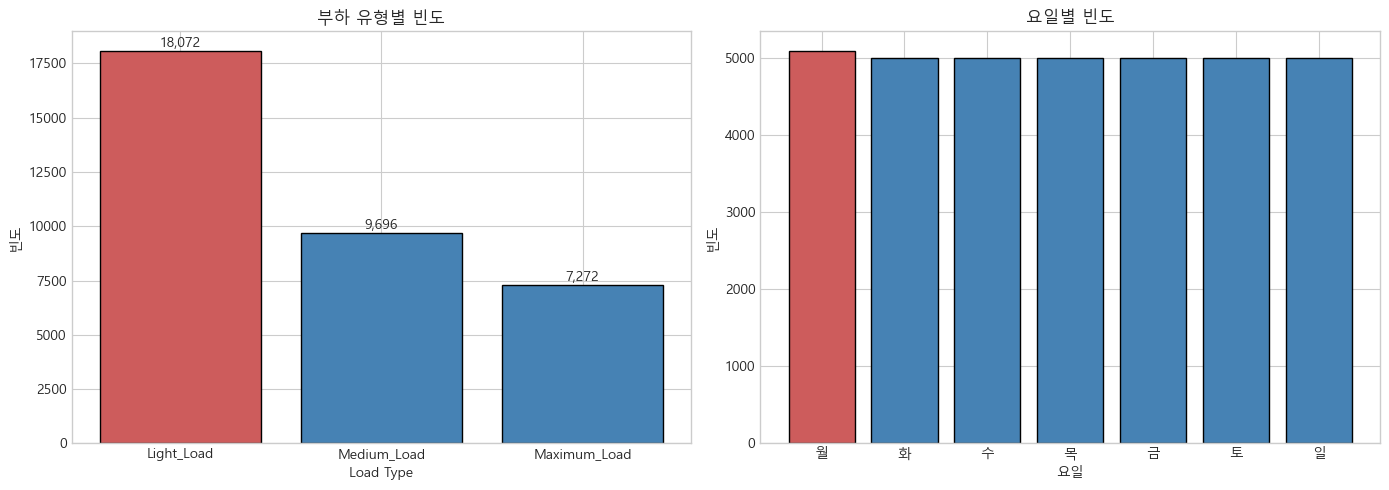

In [33]:
# 최빈값 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 부하 유형
colors1 = ['indianred' if x == mode_load_type else 'steelblue' for x in load_type_counts.index]
axes[0].bar(load_type_counts.index, load_type_counts.values, color=colors1, edgecolor='black')
axes[0].set_title('부하 유형별 빈도', fontsize=12)
axes[0].set_xlabel('Load Type')
axes[0].set_ylabel('빈도')
for i, (idx, val) in enumerate(zip(load_type_counts.index, load_type_counts.values)):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontsize=10)

# 요일별
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts_ordered = day_counts.reindex(day_order)
colors2 = ['indianred' if x == mode_day else 'steelblue' for x in day_counts_ordered.index]
axes[1].bar(range(7), day_counts_ordered.values, color=colors2, edgecolor='black')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['월', '화', '수', '목', '금', '토', '일'])
axes[1].set_title('요일별 빈도', fontsize=12)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

## 2.5 대표값 비교 종합

### 세 대표값의 비교

| 구분 | 평균(Mean) | 중앙값(Median) | 최빈값(Mode) |
|------|------------|----------------|--------------|
| **정의** | 모든 값의 합 ÷ 개수 | 정렬 후 중앙 위치 값 | 가장 빈번한 값 |
| **수식** | $\bar{x} = \frac{\sum x_i}{n}$ | $\tilde{x} = x_{(\frac{n+1}{2})}$ | $\arg\max f(x)$ |
| **이상치 영향** | 매우 민감 | 강건함 | 강건함 |
| **적합한 데이터** | 정규분포, 이상치 없음 | 비대칭, 이상치 존재 | 범주형 데이터 |
| **유일성** | 항상 유일 | 항상 유일 | 여러 개 가능 |

- **정규분포**: 평균 ≈ 중앙값 ≈ 최빈값
- **오른쪽 꼬리 분포**: 평균 > 중앙값 > 최빈값
- **왼쪽 꼬리 분포**: 평균 < 중앙값 < 최빈값

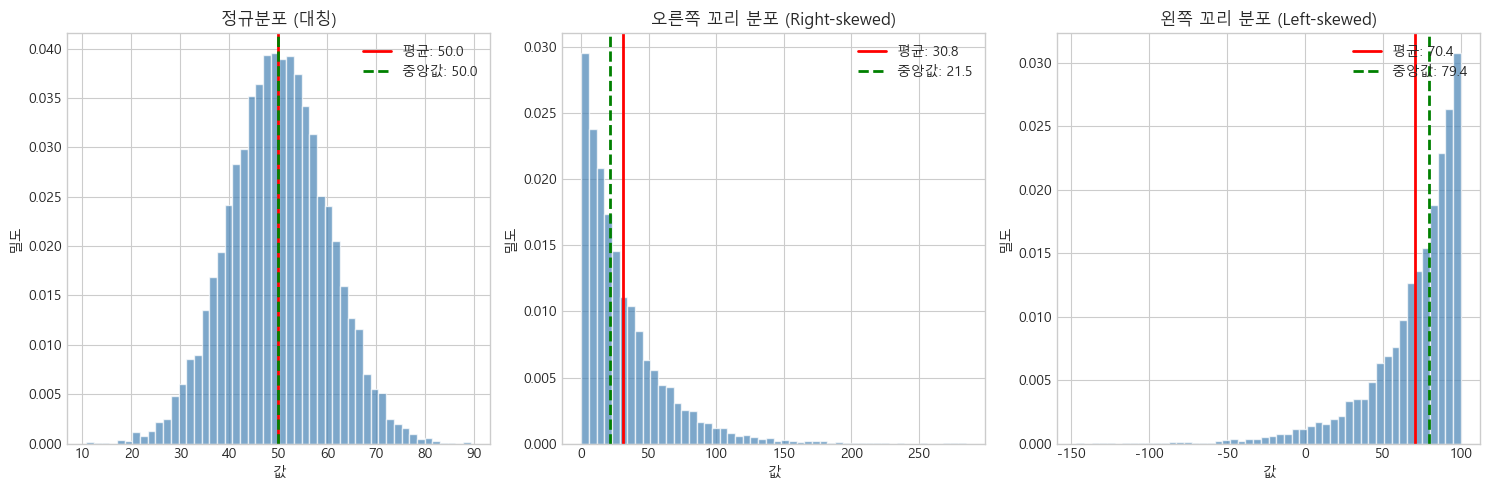


분포별 대표값 비교
분포                                평균        중앙값       평균-중앙값
------------------------------------------------------------
정규분포 (대칭)                      49.98      49.97         0.00
오른쪽 꼬리 분포 (Right-skewed)       30.80      21.48         9.32
왼쪽 꼬리 분포 (Left-skewed)         70.40      79.40        -9.01


In [34]:
# 다양한 분포에서의 대표값 비교
np.random.seed(42)

# 세 가지 분포 생성
normal_dist = np.random.normal(50, 10, 10000)  # 정규분포
right_skew = np.random.exponential(30, 10000)  # 오른쪽 꼬리 (지수분포)
left_skew = 100 - np.random.exponential(30, 10000)  # 왼쪽 꼬리

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
distributions = [
    (normal_dist, '정규분포 (대칭)', 'Normal'),
    (right_skew, '오른쪽 꼬리 분포 (Right-skewed)', 'Right-skewed'),
    (left_skew, '왼쪽 꼬리 분포 (Left-skewed)', 'Left-skewed')
]

for ax, (data, title, dist_type) in zip(axes, distributions):
    mean_v = np.mean(data)
    median_v = np.median(data)
    
    ax.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(mean_v, color='red', linewidth=2, linestyle='-', label=f'평균: {mean_v:.1f}')
    ax.axvline(median_v, color='green', linewidth=2, linestyle='--', label=f'중앙값: {median_v:.1f}')
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper right')
    ax.set_xlabel('값')
    ax.set_ylabel('밀도')

plt.tight_layout()
plt.show()

# 수치 비교
print("\n분포별 대표값 비교")
print("=" * 60)
print(f"{'분포':<25} {'평균':>10} {'중앙값':>10} {'평균-중앙값':>12}")
print("-" * 60)
for data, title, _ in distributions:
    mean_v = np.mean(data)
    median_v = np.median(data)
    print(f"{title:<25} {mean_v:>10.2f} {median_v:>10.2f} {mean_v-median_v:>12.2f}")

# 산포도(Measures of Dispersion)의 이해

## 3.1 산포도의 필요성

**산포도(Dispersion)** 는 데이터가 중심(대표값)으로부터 **얼마나 퍼져 있는지**를 나타내는 측도임.

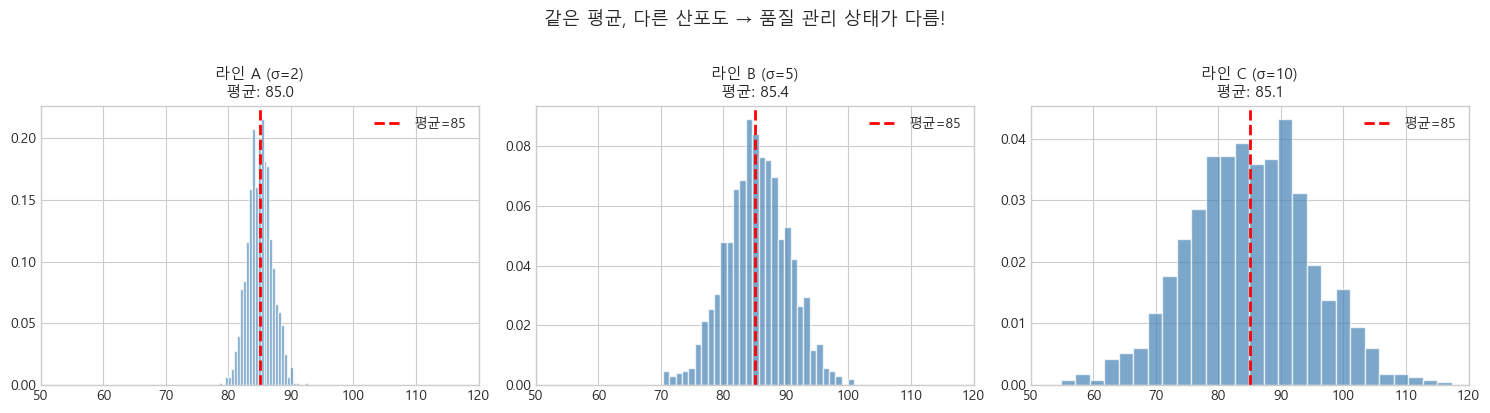

세 라인 모두 평균은 약 85°C이지만, 산포도가 다르면 품질 안정성이 다름


In [35]:
# 같은 평균, 다른 산포도 예시
np.random.seed(42)
line_a = np.random.normal(85, 2, 1000)   # 표준편차 2 (촘촘)
line_b = np.random.normal(85, 5, 1000)   # 표준편차 5 (중간)
line_c = np.random.normal(85, 10, 1000)  # 표준편차 10 (널찍)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, label, std in zip(axes, [line_a, line_b, line_c], 
                                 ['라인 A (σ=2)', '라인 B (σ=5)', '라인 C (σ=10)'],
                                 [2, 5, 10]):
    ax.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(85, color='red', linewidth=2, linestyle='--', label='평균=85')
    ax.set_xlim(50, 120)
    ax.set_title(f'{label}\n평균: {np.mean(data):.1f}', fontsize=11)
    ax.legend()

plt.suptitle('같은 평균, 다른 산포도 → 품질 관리 상태가 다름!', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("세 라인 모두 평균은 약 85°C이지만, 산포도가 다르면 품질 안정성이 다름")

## 3.2 범위(Range)

### 정의 및 수식

**범위(Range)** 는 데이터의 최대값과 최소값의 차이임.

$$R = X_{max} - X_{min}$$

### 범위의 한계

범위는 계산이 간단하지만 다음과 같은 **한계**가 있음:
- 극단값 2개만 사용 (나머지 데이터 무시)
- **이상치에 매우 민감**
- 데이터 분포 형태를 반영하지 못함

### 계산 예시

In [36]:
# Steel Industry 데이터 범위 계산
usage = df['Usage_kWh']

x_max = usage.max()
x_min = usage.min()
range_val = x_max - x_min

print("에너지 소비량 범위 계산")
print("=" * 50)
print(f"최대값 (Xmax): {x_max:.4f} kWh")
print(f"최소값 (Xmin): {x_min:.4f} kWh")
print(f"범위 (Range): {range_val:.4f} kWh")

에너지 소비량 범위 계산
최대값 (Xmax): 157.1800 kWh
최소값 (Xmin): 0.0000 kWh
범위 (Range): 157.1800 kWh


## 3.3 분산(Variance)

### 정의 및 수식

**분산(Variance)** 은 각 데이터 값이 평균으로부터 떨어진 거리(편차)의 제곱 평균임.

**모분산 (Population Variance):**

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2$$

**표본분산 (Sample Variance):**

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

> **왜 n-1로 나누는가?**

> 표본분산에서 $n$ 대신 $n-1$로 나누는 것을 **베셀 보정(Bessel's correction)** 이라 함. 

> 표본평균 $\bar{x}$를 계산하는 데 이미 하나의 자유도가 사용되었기 때문에, 

> 불편추정량(unbiased estimator)을 얻기 위해 자유도(degrees of freedom) $n-1$로 나눔.


### 수식 전개 예시

**예제 데이터**: $x = \{84, 85, 86, 87\}$

**Step 1: 평균 계산**
$$\bar{x} = \frac{84 + 85 + 86 + 87}{4} = \frac{342}{4} = 85.5$$

**Step 2: 편차 계산**
$$x_1 - \bar{x} = 84 - 85.5 = -1.5$$
$$x_2 - \bar{x} = 85 - 85.5 = -0.5$$
$$x_3 - \bar{x} = 86 - 85.5 = +0.5$$
$$x_4 - \bar{x} = 87 - 85.5 = +1.5$$

**Step 3: 편차제곱 계산**
$$(-1.5)^2 = 2.25, \quad (-0.5)^2 = 0.25, \quad (0.5)^2 = 0.25, \quad (1.5)^2 = 2.25$$

**Step 4: 편차제곱합(Sum of Squares)**
$$SS = 2.25 + 0.25 + 0.25 + 2.25 = 5.0$$

**Step 5: 분산 계산**
$$s^2 = \frac{SS}{n-1} = \frac{5.0}{4-1} = \frac{5.0}{3} \approx 1.67$$

In [43]:
# 분산 계산 과정 상세
data = np.array([84, 85, 86, 87])
n = len(data)
mean = data.mean()

print("분산 계산 과정")
print("=" * 60)
print(f"데이터: {data}")
print(f"평균 (x̄): {mean}")
print()

# 단계별 계산 테이블
print(f"{'i':<5} {'xᵢ':<10} {'xᵢ - x̄':<15} {'(xᵢ - x̄)²':<15}")
print("-" * 45)
deviations = data - mean
squared_deviations = deviations ** 2
for i, (x, dev, sq_dev) in enumerate(zip(data, deviations, squared_deviations), 1):
    print(f"{i:<5} {x:<10} {dev:<15.2f} {sq_dev:<15.2f}")
print("-" * 45)
ss = squared_deviations.sum()
print(f"{'합계':<5} {'':<10} {deviations.sum():<15.2f} {ss:<15.2f}")
print()
print(f"편차제곱합 (SS): {ss:.2f}")
print(f"표본분산 (s²): SS/(n-1) = {ss:.2f}/{n-1} = {ss/(n-1):.4f}")

print(f"\nNumPy 검증: np.var(data, ddof=1) = {np.var(data, ddof=1):.4f}")

분산 계산 과정
데이터: [84 85 86 87]
평균 (x̄): 85.5

i     xᵢ         xᵢ - x̄         (xᵢ - x̄)²     
---------------------------------------------
1     84         -1.50           2.25           
2     85         -0.50           0.25           
3     86         0.50            0.25           
4     87         1.50            2.25           
---------------------------------------------
합계               0.00            5.00           

편차제곱합 (SS): 5.00
표본분산 (s²): SS/(n-1) = 5.00/3 = 1.6667

NumPy 검증: np.var(data, ddof=1) = 1.6667


In [42]:
# Steel Industry 데이터에서 분산 계산
usage = df['Usage_kWh']
n = len(usage)
mean_usage = usage.mean()

# 편차제곱합 계산
deviations = usage - mean_usage
squared_deviations = deviations ** 2
ss = squared_deviations.sum()

# 표본분산
sample_variance = ss / (n - 1)

print("에너지 소비량 분산 계산")
print("=" * 60)
print(f"샘플 수 (n): {n:,}")
print(f"평균 (x̄): {mean_usage:.4f} kWh")
print(f"편차제곱합 (SS): {ss:,.2f}")
print(f"표본분산 (s²): {sample_variance:.4f} kWh²")

print(f"\n검증 (NumPy): {np.var(usage, ddof=1):.4f} kWh²")
print(f"검증 (Pandas): {usage.var():.4f} kWh²")

에너지 소비량 분산 계산
샘플 수 (n): 35,040
평균 (x̄): 27.3869 kWh
편차제곱합 (SS): 39,192,051.23
표본분산 (s²): 1118.5265 kWh²

검증 (NumPy): 1118.5265 kWh²
검증 (Pandas): 1118.5265 kWh²


## 3.4 표준편차(Standard Deviation)

###  정의 및 수식

**표준편차(Standard Deviation)** 는 분산의 제곱근임.

**모표준편차:**

$$\sigma = \sqrt{\sigma^2} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}$$

**표본표준편차:**

$$s = \sqrt{s^2} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

### 표준편차의 의미

표준편차는 데이터가 평균으로부터 **평균적으로 얼마나 떨어져 있는지**를 원래 단위로 표현함.

- **분산**: 단위가 제곱됨 (예: kWh²)
- **표준편차**: 원래 단위와 동일 (예: kWh)

In [41]:
# 표준편차 계산
variance = usage.var()
std_dev = np.sqrt(variance)

print("표준편차 계산")
print("=" * 50)
print(f"분산 (s²): {variance:.4f} kWh²")
print(f"표준편차 (s): √{variance:.4f} = {std_dev:.4f} kWh")

print(f"\n검증 (NumPy): {np.std(usage, ddof=1):.4f} kWh")
print(f"검증 (Pandas): {usage.std():.4f} kWh")

표준편차 계산
분산 (s²): 1118.5265 kWh²
표준편차 (s): √1118.5265 = 33.4444 kWh

검증 (NumPy): 33.4444 kWh
검증 (Pandas): 33.4444 kWh


### 68-95-99.7 규칙 (다음 차시에서..)

**정규분포**를 따르는 데이터에서:

- **68.27%** 의 데이터가 $\mu \pm 1\sigma$ 범위 내에 존재
- **95.45%** 의 데이터가 $\mu \pm 2\sigma$ 범위 내에 존재
- **99.73%** 의 데이터가 $\mu \pm 3\sigma$ 범위 내에 존재

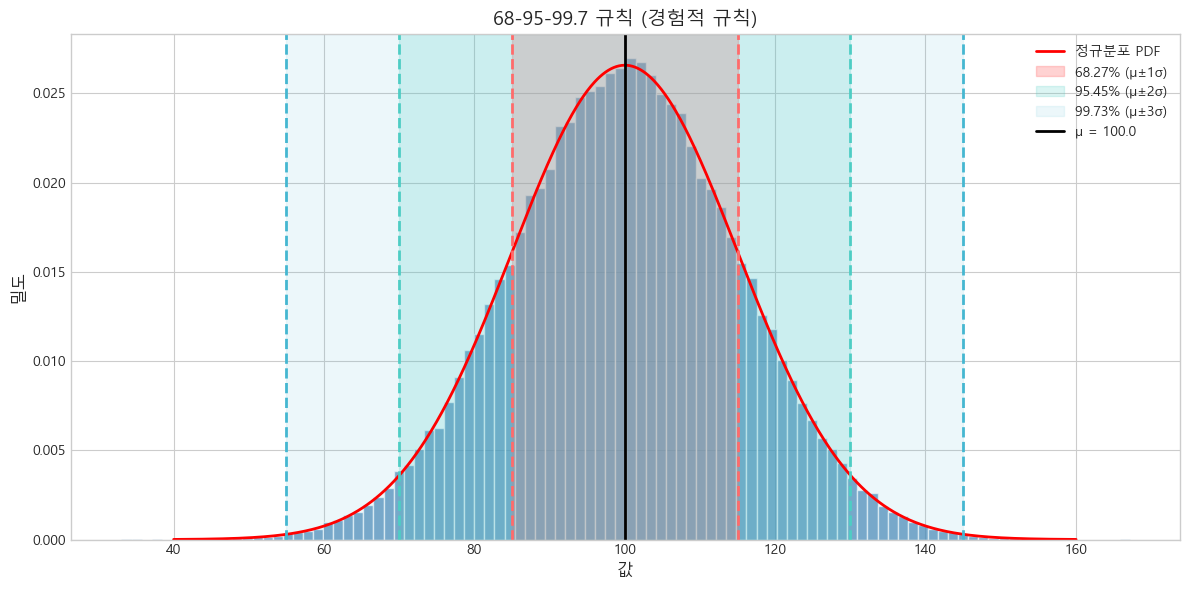

68-95-99.7 규칙 검증
μ ± 1σ 범위 내 비율: 68.22% (이론값: 68.27%)
μ ± 2σ 범위 내 비율: 95.47% (이론값: 95.45%)
μ ± 3σ 범위 내 비율: 99.74% (이론값: 99.73%)


In [44]:
# 68-95-99.7 규칙 시각화
np.random.seed(42)
normal_data = np.random.normal(100, 15, 100000)
mu = normal_data.mean()
sigma = normal_data.std()

fig, ax = plt.subplots(figsize=(12, 6))

# 히스토그램
n, bins, patches = ax.hist(normal_data, bins=100, density=True, alpha=0.7, 
                           color='steelblue', edgecolor='white')

# 정규분포 곡선
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = stats.norm.pdf(x, mu, sigma)
ax.plot(x, pdf, 'r-', linewidth=2, label='정규분포 PDF')

# 범위 표시
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['68.27% (μ±1σ)', '95.45% (μ±2σ)', '99.73% (μ±3σ)']
alphas = [0.3, 0.2, 0.1]

for i, (mult, color, label, alpha) in enumerate(zip([1, 2, 3], colors, labels, alphas)):
    ax.axvline(mu - mult*sigma, color=color, linestyle='--', linewidth=2)
    ax.axvline(mu + mult*sigma, color=color, linestyle='--', linewidth=2)
    ax.axvspan(mu - mult*sigma, mu + mult*sigma, alpha=alpha, color=color, label=label)

ax.axvline(mu, color='black', linestyle='-', linewidth=2, label=f'μ = {mu:.1f}')
ax.set_xlabel('값', fontsize=12)
ax.set_ylabel('밀도', fontsize=12)
ax.set_title('68-95-99.7 규칙 (경험적 규칙)', fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 실제 비율 계산
within_1sigma = np.sum((normal_data >= mu - sigma) & (normal_data <= mu + sigma)) / len(normal_data) * 100
within_2sigma = np.sum((normal_data >= mu - 2*sigma) & (normal_data <= mu + 2*sigma)) / len(normal_data) * 100
within_3sigma = np.sum((normal_data >= mu - 3*sigma) & (normal_data <= mu + 3*sigma)) / len(normal_data) * 100

print("68-95-99.7 규칙 검증")
print("=" * 50)
print(f"μ ± 1σ 범위 내 비율: {within_1sigma:.2f}% (이론값: 68.27%)")
print(f"μ ± 2σ 범위 내 비율: {within_2sigma:.2f}% (이론값: 95.45%)")
print(f"μ ± 3σ 범위 내 비율: {within_3sigma:.2f}% (이론값: 99.73%)")

### 실무에서의 활용: 관리도

**관리도(Control Chart)** 는 제조 공정의 품질을 모니터링하는 데 표준편차를 활용함.

- **중심선(CL, Center Line)**: $\mu$
- **상한 관리한계(UCL, Upper Control Limit)**: $\mu + 3\sigma$
- **하한 관리한계(LCL, Lower Control Limit)**: $\mu - 3\sigma$

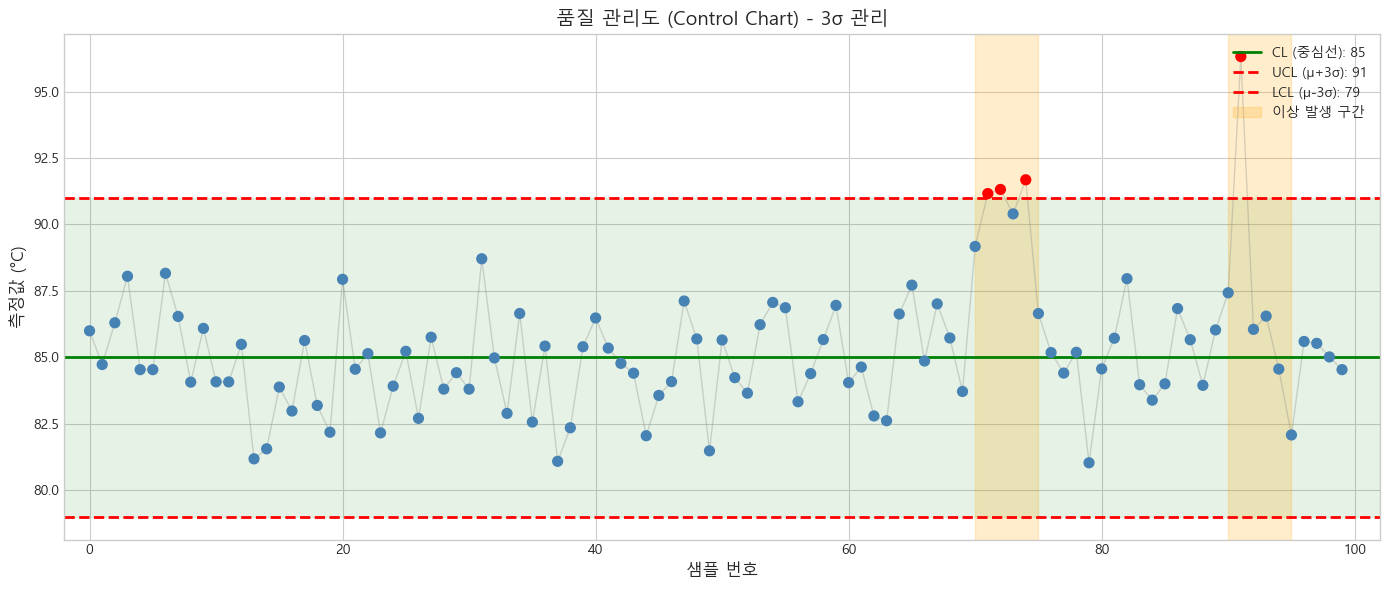

관리한계 벗어난 데이터 포인트: 4개
  샘플 #71: 91.16°C
  샘플 #72: 91.31°C
  샘플 #74: 91.68°C
  샘플 #91: 96.32°C


In [45]:
# 관리도 시뮬레이션
np.random.seed(42)
n_samples = 100

# 정상 공정 데이터 + 이상 발생 시점
process_data = np.random.normal(85, 2, n_samples)
# 70번째부터 공정 이상 발생 시뮬레이션
process_data[70:75] = np.random.normal(92, 2, 5)  # 평균 이동
process_data[90:95] = np.random.normal(85, 6, 5)  # 산포 증가

mu = 85
sigma = 2
ucl = mu + 3 * sigma
lcl = mu - 3 * sigma

fig, ax = plt.subplots(figsize=(14, 6))

# 데이터 플롯
colors = ['red' if (x > ucl or x < lcl) else 'steelblue' for x in process_data]
ax.scatter(range(n_samples), process_data, c=colors, s=50, zorder=5)
ax.plot(range(n_samples), process_data, 'gray', alpha=0.3, linewidth=1)

# 관리한계선
ax.axhline(mu, color='green', linestyle='-', linewidth=2, label=f'CL (중심선): {mu}')
ax.axhline(ucl, color='red', linestyle='--', linewidth=2, label=f'UCL (μ+3σ): {ucl}')
ax.axhline(lcl, color='red', linestyle='--', linewidth=2, label=f'LCL (μ-3σ): {lcl}')
ax.axhspan(lcl, ucl, alpha=0.1, color='green')

# 이상 구간 표시
ax.axvspan(70, 75, alpha=0.2, color='orange', label='이상 발생 구간')
ax.axvspan(90, 95, alpha=0.2, color='orange')

ax.set_xlabel('샘플 번호', fontsize=12)
ax.set_ylabel('측정값 (°C)', fontsize=12)
ax.set_title('품질 관리도 (Control Chart) - 3σ 관리', fontsize=14)
ax.legend(loc='upper right')
ax.set_xlim(-2, n_samples + 2)
plt.tight_layout()
plt.show()

# 이상치 탐지
outliers = [(i, x) for i, x in enumerate(process_data) if x > ucl or x < lcl]
print(f"관리한계 벗어난 데이터 포인트: {len(outliers)}개")
for idx, val in outliers:
    print(f"  샘플 #{idx}: {val:.2f}°C")

## 3.5 사분위수와 IQR

### 3.5.1 분위수(Quantile)의 정의

**분위수(Quantile)** 는 데이터를 특정 비율로 나누는 점임.

**주요 분위수:**
- **4분위수(Quartile)**: 데이터를 4등분
  - Q1 (25번째 백분위수): 하위 25% 지점
  - Q2 (50번째 백분위수): 중앙값
  - Q3 (75번째 백분위수): 상위 25% 지점

**p번째 백분위수(Percentile) 계산:**

$$P_p = x_{(\lceil np \rceil)}$$

(여기서 $\lceil \cdot \rceil$은 올림 함수읻다)

In [46]:
# Steel Industry 데이터 사분위수 계산
usage = df['Usage_kWh']

q1 = usage.quantile(0.25)
q2 = usage.quantile(0.50)  # 중앙값
q3 = usage.quantile(0.75)

print("에너지 소비량 사분위수")
print("=" * 50)
print(f"Q1 (25%): {q1:.4f} kWh")
print(f"Q2 (50%, 중앙값): {q2:.4f} kWh")
print(f"Q3 (75%): {q3:.4f} kWh")
print(f"\n검증 (np.percentile):")
print(f"Q1: {np.percentile(usage, 25):.4f}")
print(f"Q2: {np.percentile(usage, 50):.4f}")
print(f"Q3: {np.percentile(usage, 75):.4f}")

에너지 소비량 사분위수
Q1 (25%): 3.2000 kWh
Q2 (50%, 중앙값): 4.5700 kWh
Q3 (75%): 51.2375 kWh

검증 (np.percentile):
Q1: 3.2000
Q2: 4.5700
Q3: 51.2375


#### 사분위범위(IQR)

**사분위범위(Interquartile Range, IQR)** 는 Q3과 Q1의 차이로, 중앙 50% 데이터의 범위를 나타냄.

$$IQR = Q3 - Q1$$

In [47]:
# IQR 계산
iqr = q3 - q1

print("IQR (사분위범위) 계산")
print("=" * 50)
print(f"Q3: {q3:.4f} kWh")
print(f"Q1: {q1:.4f} kWh")
print(f"IQR = Q3 - Q1 = {q3:.4f} - {q1:.4f} = {iqr:.4f} kWh")

IQR (사분위범위) 계산
Q3: 51.2375 kWh
Q1: 3.2000 kWh
IQR = Q3 - Q1 = 51.2375 - 3.2000 = 48.0375 kWh


### IQR을 이용한 이상치 탐지

**Tukey's Fences** 방법을 이용한 이상치 기준:

$$\text{이상치 하한} = Q1 - 1.5 \times IQR$$
$$\text{이상치 상한} = Q3 + 1.5 \times IQR$$

이 범위를 벗어나는 값을 **Outlier** 로 판정함.

In [48]:
# 이상치 탐지
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers_mask = (usage < lower_fence) | (usage > upper_fence)
n_outliers = outliers_mask.sum()

print("IQR 기반 이상치 탐지")
print("=" * 50)
print(f"Q1: {q1:.4f} kWh")
print(f"Q3: {q3:.4f} kWh")
print(f"IQR: {iqr:.4f} kWh")
print(f"\n이상치 하한: Q1 - 1.5×IQR = {q1:.4f} - 1.5×{iqr:.4f} = {lower_fence:.4f} kWh")
print(f"이상치 상한: Q3 + 1.5×IQR = {q3:.4f} + 1.5×{iqr:.4f} = {upper_fence:.4f} kWh")
print(f"\n이상치 개수: {n_outliers:,}개 ({n_outliers/len(usage)*100:.2f}%)")

IQR 기반 이상치 탐지
Q1: 3.2000 kWh
Q3: 51.2375 kWh
IQR: 48.0375 kWh

이상치 하한: Q1 - 1.5×IQR = 3.2000 - 1.5×48.0375 = -68.8562 kWh
이상치 상한: Q3 + 1.5×IQR = 51.2375 + 1.5×48.0375 = 123.2937 kWh

이상치 개수: 328개 (0.94%)


### 3.6 describe() 함수로 한 번에 확인

**describe() 출력 해석:**
- **count**: 결측치 제외 데이터 개수
- **mean**: 평균
- **std**: 표준편차
- **min**: 최소값
- **25%**: Q1 (1사분위수)
- **50%**: Q2 (중앙값)
- **75%**: Q3 (3사분위수)
- **max**: 최대값

In [49]:
# Pandas describe() 활용
print("에너지 소비량 기술통계 요약")
print("=" * 50)
print(df['Usage_kWh'].describe())

에너지 소비량 기술통계 요약
count   35040.0000
mean       27.3869
std        33.4444
min         0.0000
25%         3.2000
50%         4.5700
75%        51.2375
max       157.1800
Name: Usage_kWh, dtype: float64


# 탐색적 데이터 분석(EDA)과 시각화

## 4.1 탐색적 데이터 분석(EDA)이란?

**탐색적 데이터 분석(Exploratory Data Analysis, EDA)** 은 본격적인 분석이나 모델링 전에 데이터의 **특성, 패턴, 이상치, 관계** 를 시각화와 통계를 통해 파악하는 과정임.

**EDA의 목적:**
1. 데이터 품질 확인 (결측치, 이상치)
2. 변수 분포 파악
3. 변수 간 관계 탐색
4. 가설 수립
5. 전처리 방향 결정

## 4.2 히스토그램(Histogram)

### 4.2.1 정의 및 원리

**히스토그램**은 연속형 데이터를 **구간(bin)** 으로 나누고, 각 구간에 속하는 데이터의 **빈도**를 막대 높이로 표현한 그래프임.

**구성 요소:**
- **x축**: 데이터 값의 구간 (bin)
- **y축**: 빈도(frequency) 또는 밀도(density)

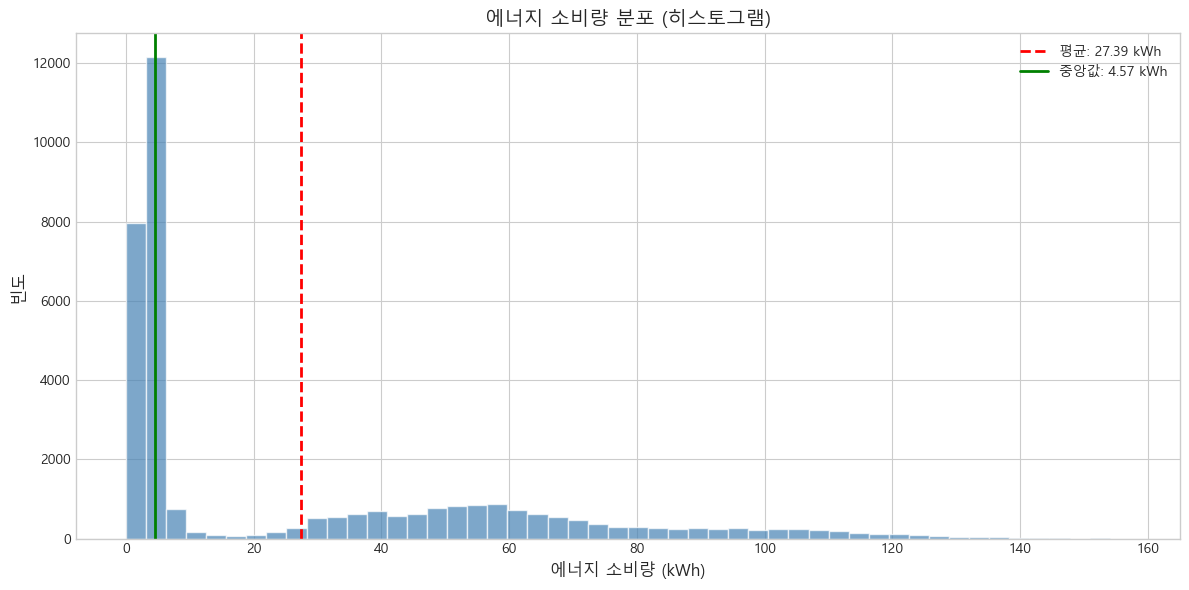

In [50]:
# 에너지 소비량 히스토그램
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['Usage_kWh'], bins=50, edgecolor='white', alpha=0.7, color='steelblue')
ax.axvline(df['Usage_kWh'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'평균: {df["Usage_kWh"].mean():.2f} kWh')
ax.axvline(df['Usage_kWh'].median(), color='green', linestyle='-', linewidth=2, 
           label=f'중앙값: {df["Usage_kWh"].median():.2f} kWh')

ax.set_xlabel('에너지 소비량 (kWh)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title('에너지 소비량 분포 (히스토그램)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

#### 구간 수(bins) 선택의 영향

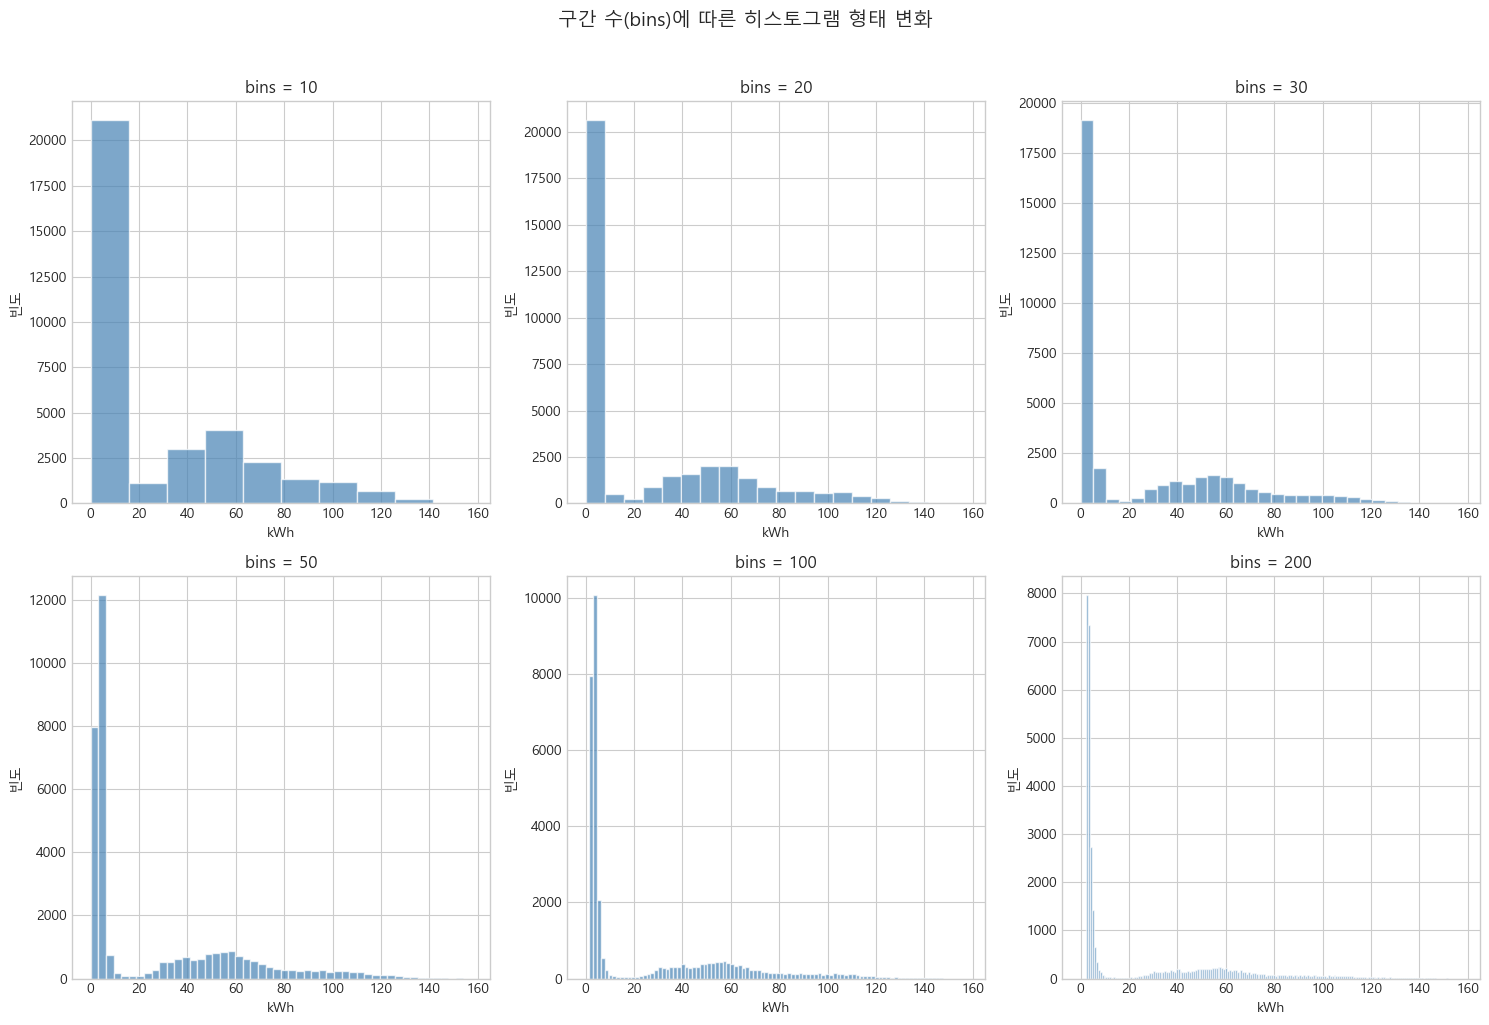

구간 수 선택 가이드:
- bins가 너무 적음: 세부 패턴 손실
- bins가 너무 많음: 과도한 노이즈, 패턴 파악 어려움

- Sturges 규칙: bins = 1 + log₂(n)
- Freedman-Diaconis 규칙: bin_width = 2 × IQR × n^(-1/3)


In [52]:
# 구간 수에 따른 히스토그램 변화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
bins_list = [10, 20, 30, 50, 100, 200]

for ax, bins in zip(axes.flatten(), bins_list):
    ax.hist(df['Usage_kWh'], bins=bins, edgecolor='white', alpha=0.7, color='steelblue')
    ax.set_title(f'bins = {bins}', fontsize=12)
    ax.set_xlabel('kWh')
    ax.set_ylabel('빈도')

plt.suptitle('구간 수(bins)에 따른 히스토그램 형태 변화', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("구간 수 선택 가이드:")
print("- bins가 너무 적음: 세부 패턴 손실")
print("- bins가 너무 많음: 과도한 노이즈, 패턴 파악 어려움")
print("")
print("- Sturges 규칙: bins = 1 + log₂(n)")
print("- Freedman-Diaconis 규칙: bin_width = 2 × IQR × n^(-1/3)")

### 밀도 히스토그램 (정규화)

**밀도 히스토그램**은 y축을 빈도(frequency)가 아닌 **밀도(density)** 로 표현하여, 히스토그램 아래 면적의 합이 1이 되도록 정규화한 것임. 이를 통해 서로 다른 크기의 데이터셋 간 분포 형태를 직접 비교할 수 있음.

**KDE(Kernel Density Estimation, 커널 밀도 추정)** 는 히스토그램의 계단 형태를 부드러운 연속 곡선으로 추정하는 비모수적 방법임. 각 데이터 포인트에 커널 함수(주로 가우시안)를 적용하고 이를 합산하여 전체 분포의 형태를 추정함.

**사용 목적:**
- 분포의 연속적인 형태를 파악할 때
- 여러 그룹의 분포를 겹쳐서 비교할 때
- 이봉분포(bimodal) 등 복잡한 분포 형태를 탐지할 때

**결과 해석 포인트:**
- KDE 곡선의 **피크(peak) 위치**가 데이터가 가장 밀집된 영역을 나타냄
- 곡선의 **너비**가 넓을수록 데이터의 산포가 큼
- **여러 개의 피크**가 있다면 이봉분포 또는 다봉분포로, 서로 다른 특성을 가진 하위 그룹이 존재할 가능성을 시사함
- 제조 현장에서는 피크가 목표값(target) 근처에 있는지, 분포가 규격 한계 내에 있는지를 확인하는 데 활용함

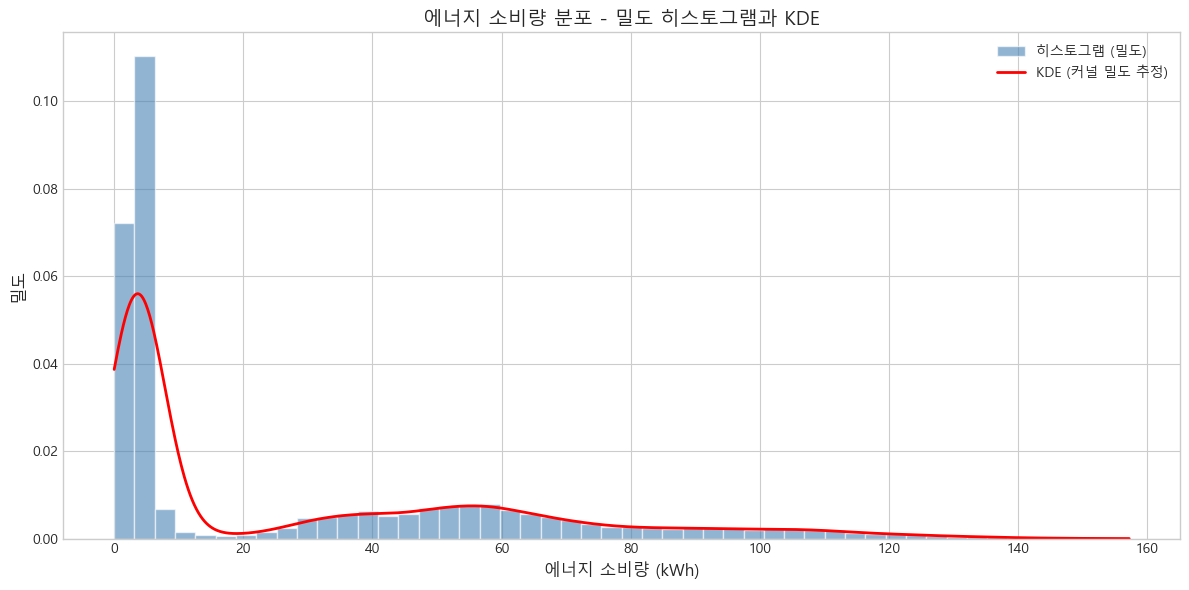

In [55]:
# 밀도 히스토그램과 KDE(커널 밀도 추정)
fig, ax = plt.subplots(figsize=(12, 6))

# 밀도 히스토그램
ax.hist(df['Usage_kWh'], bins=50, density=True, edgecolor='white', alpha=0.6, 
        color='steelblue', label='히스토그램 (밀도)')

# KDE (Kernel Density Estimation)
from scipy.stats import gaussian_kde
kde = gaussian_kde(df['Usage_kWh'])
x_range = np.linspace(df['Usage_kWh'].min(), df['Usage_kWh'].max(), 1000)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE (커널 밀도 추정)')

ax.set_xlabel('에너지 소비량 (kWh)', fontsize=12)
ax.set_ylabel('밀도', fontsize=12)
ax.set_title('에너지 소비량 분포 - 밀도 히스토그램과 KDE', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

#### 히스토그램 해석 가이드

히스토그램을 해석할 때는 다음 **4가지 관점**에서 분석해야 함:

1. **중심 위치(Central Location)**: 데이터가 어느 값 주변에 집중되어 있는가?
2. **퍼짐 정도(Spread)**: 데이터가 얼마나 넓게/좁게 분포하는가?
3. **대칭성(Symmetry)**: 좌우 대칭인가, 한쪽으로 치우쳐 있는가?
4. **이상치(Outliers)**: 주 분포에서 벗어난 극단값이 있는가?

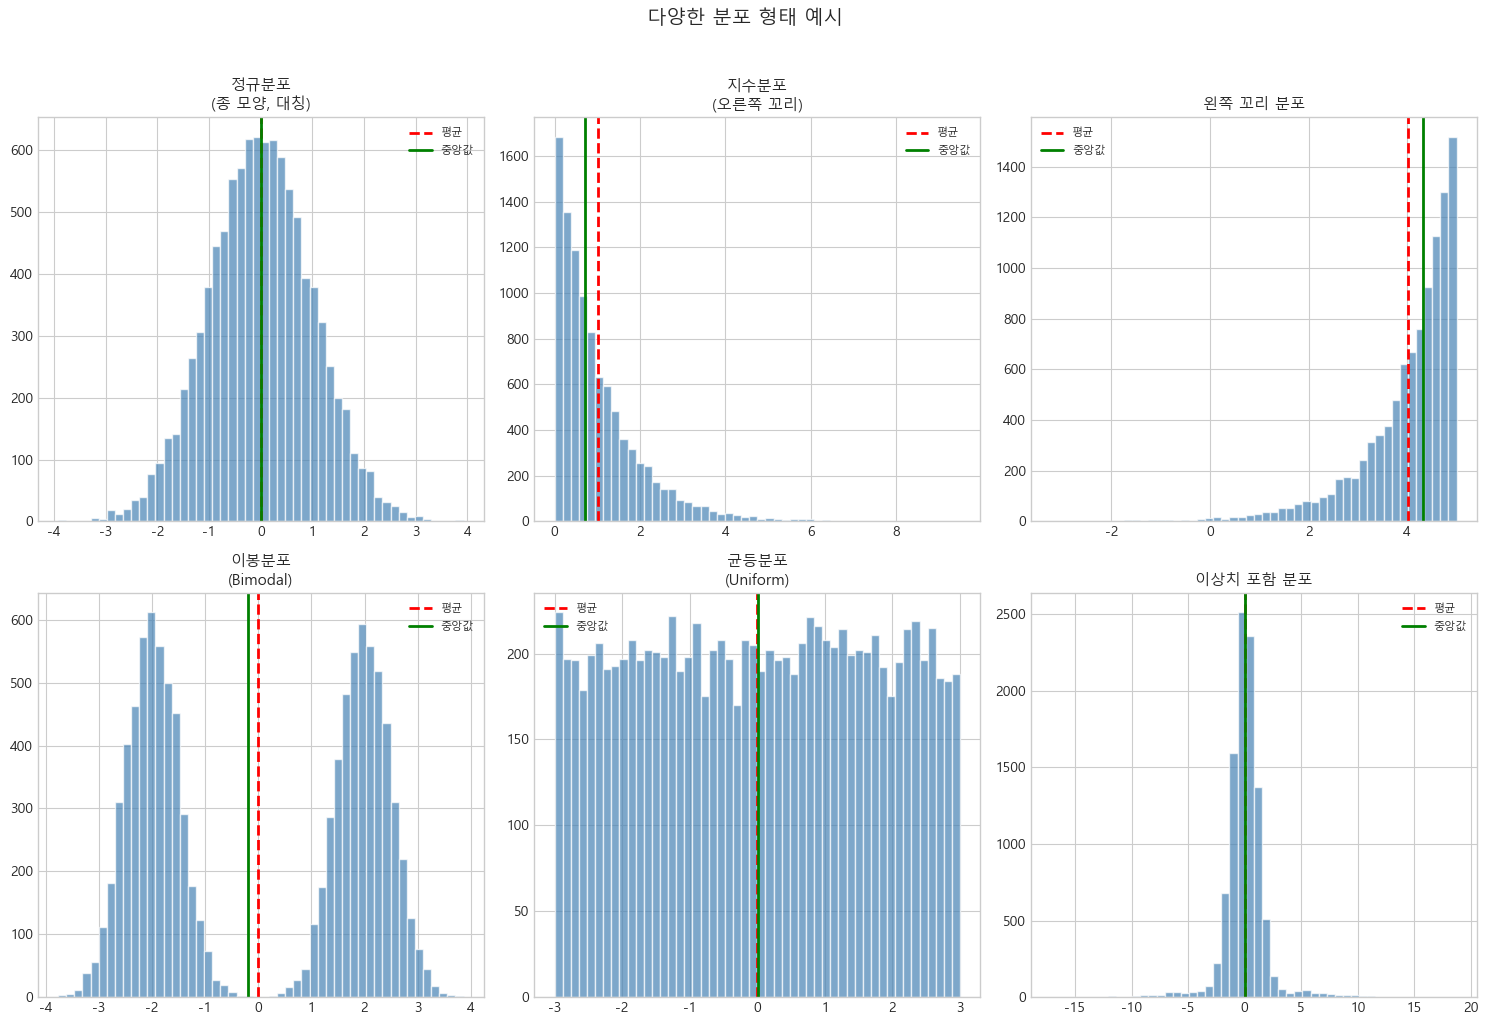

In [56]:
np.random.seed(42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

distributions = [
    (np.random.normal(0, 1, 10000), '정규분포\n(종 모양, 대칭)'),
    (np.random.exponential(1, 10000), '지수분포\n(오른쪽 꼬리)'),
    (5 - np.random.exponential(1, 10000), '왼쪽 꼬리 분포'),
    (np.concatenate([np.random.normal(-2, 0.5, 5000), np.random.normal(2, 0.5, 5000)]), 
     '이봉분포\n(Bimodal)'),
    (np.random.uniform(-3, 3, 10000), '균등분포\n(Uniform)'),
    (np.concatenate([np.random.normal(0, 1, 9000), np.random.normal(0, 1, 1000) * 5]), 
     '이상치 포함 분포')
]

for ax, (data, title) in zip(axes.flatten(), distributions):
    ax.hist(data, bins=50, edgecolor='white', alpha=0.7, color='steelblue')
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label='평균')
    ax.axvline(np.median(data), color='green', linestyle='-', linewidth=2, label='중앙값')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('다양한 분포 형태 예시', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

| 분포 형태 | 특징 | 평균 vs 중앙값 | 제조 현장 예시 |
|-----------|------|----------------|----------------|
| **정규분포** | 종 모양, 좌우 대칭 | 평균 ≈ 중앙값 | 안정적인 공정에서의 품질 특성 |
| **오른쪽 꼬리** | 왼쪽에 몰리고 오른쪽으로 긴 꼬리 | 평균 > 중앙값 | 고장 간 시간(MTBF), 대기 시간 |
| **왼쪽 꼬리** | 오른쪽에 몰리고 왼쪽으로 긴 꼬리 | 평균 < 중앙값 | 수명 데이터(상한이 있는 경우) |
| **이봉분포** | 두 개의 피크 | 위치에 따라 상이 | 2개 설비 혼합, 주간/야간 구분 |
| **균등분포** | 모든 값이 비슷한 빈도 | 평균 ≈ 중앙값 | 무작위 샘플링, 균일 혼합 |
| **이상치 포함** | 주 분포 + 극단값 | 평균이 이상치 방향으로 치우침 | 센서 오류, 비정상 가동 |

- **이봉분포**가 관찰되면 두 가지 다른 조건(예: 2개 라인, 주간/야간 교대, 원자재 로트 차이)이 혼합된 것일 수 있으므로 층별 분석(stratification)이 필요함
- **오른쪽 꼬리 분포**는 공정 이상이나 설비 불량 시 발생하는 패턴일 수 있으므로, 꼬리 부분의 데이터를 집중적으로 분석해야 함

## 4.3 상자그림(Box Plot)

### 4.3.1 정의 및 구성요소

**상자그림(Box Plot, 박스플롯)** 은 John Tukey가 고안한 시각화 도구로, 데이터의 분포를 **5가지 요약 통계량(Five-Number Summary)** 과 **이상치**를 통해 간결하게 표현함.

**사용 목적:**
- 데이터 분포의 중심, 퍼짐, 대칭성을 한눈에 파악
- **이상치를 즉시 식별**
- **여러 그룹 간 분포를 쉽게 비교**

**구성요소 상세:**
```
                    이상치 ○  ← Q3 + 1.5×IQR 초과 또는 Q1 - 1.5×IQR 미만인 값
                       │
    ┌──────────────────┤──────────────────┐
    │                  │                  │  ← 상단 수염(whisker): Q3 + 1.5×IQR 이내의 최대값
    │  ┌───────────────┴───────────────┐  │
    │  │                               │  │  ← Q3 (75번째 백분위수): 상위 25% 경계
    │  │           ─────────           │  │  ← Q2 (중앙값): 50번째 백분위수
    │  │                               │  │  ← Q1 (25번째 백분위수): 하위 25% 경계
    │  └───────────────────────────────┘  │
    │                                     │  ← 하단 수염(whisker): Q1 - 1.5×IQR 이상의 최소값
    └─────────────────────────────────────┘
                       │
                    이상치 ○
```

**상자의 높이(IQR)** 는 데이터의 중앙 50%가 분포하는 범위를 나타내므로, 상자가 클수록 데이터의 산포가 큼.

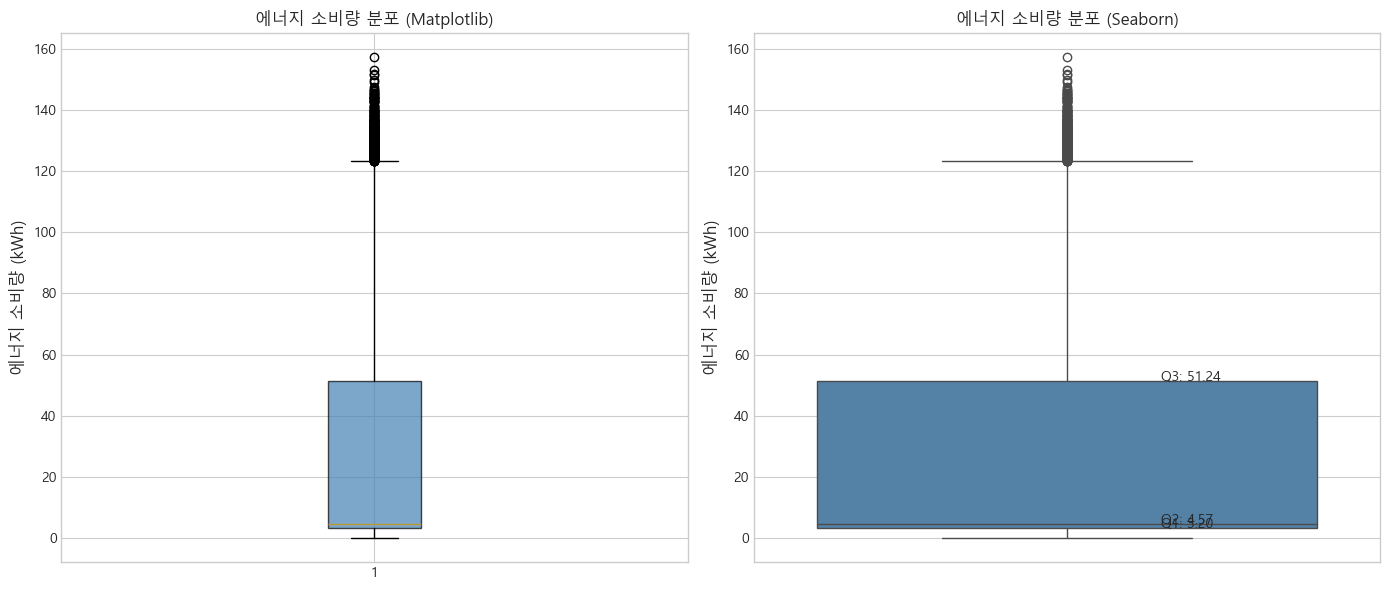

In [57]:
# 에너지 소비량 상자그림
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matplotlib 기본 boxplot
bp = axes[0].boxplot(df['Usage_kWh'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
axes[0].set_ylabel('에너지 소비량 (kWh)', fontsize=12)
axes[0].set_title('에너지 소비량 분포 (Matplotlib)', fontsize=12)

# Seaborn boxplot
sns.boxplot(y=df['Usage_kWh'], ax=axes[1], color='steelblue')
axes[1].set_ylabel('에너지 소비량 (kWh)', fontsize=12)
axes[1].set_title('에너지 소비량 분포 (Seaborn)', fontsize=12)

# 통계값 표시
q1 = df['Usage_kWh'].quantile(0.25)
q2 = df['Usage_kWh'].quantile(0.50)
q3 = df['Usage_kWh'].quantile(0.75)
axes[1].annotate(f'Q3: {q3:.2f}', xy=(0.15, q3), fontsize=10)
axes[1].annotate(f'Q2: {q2:.2f}', xy=(0.15, q2), fontsize=10)
axes[1].annotate(f'Q1: {q1:.2f}', xy=(0.15, q1), fontsize=10)

plt.tight_layout()
plt.show()

**결과 해석 방법:**
- **상자의 위치**: 데이터의 중심이 어디에 있는지 파악 (Q2 = 중앙값)
- **상자의 높이**: IQR의 크기로, 데이터의 산포 정도를 나타냄
- **중앙값의 위치**: 상자 내에서 중앙값이 어디에 있는지로 대칭성 판단
  - 상자 중앙에 있으면 → 대칭 분포
  - 아래쪽에 치우쳐 있으면 → 오른쪽 꼬리 분포
  - 위쪽에 치우쳐 있으면 → 왼쪽 꼬리 분포
- **수염의 길이**: 긴 수염은 해당 방향으로 데이터가 더 퍼져 있음을 의미
- **이상치 점의 개수와 위치**: 공정 이상, 측정 오류 등의 징후

### 그룹별 상자그림 비교

상자그림의 **가장 강력한 활용법**은 여러 그룹(범주)의 분포를 나란히 비교하는 것임. 이를 통해 그룹 간 차이를 직관적으로 파악할 수 있음.

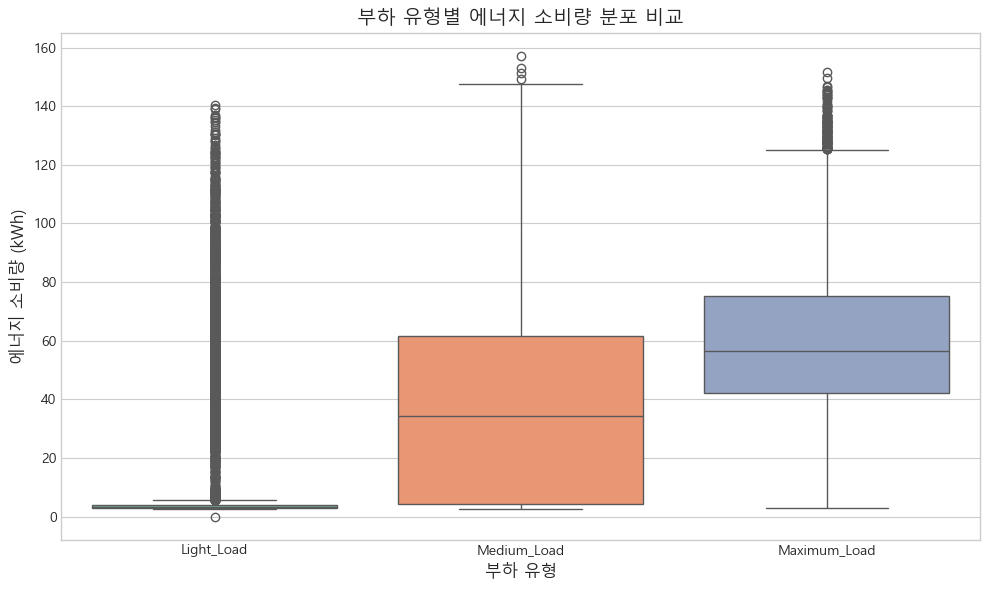

부하 유형별 기술통계
                  count    mean     std    min     25%     50%     75%  \
Load_Type                                                                
Light_Load   18072.0000  8.6300 17.9100 0.0000  2.9500  3.3100  4.0300   
Maximum_Load  7272.0000 59.2700 29.7500 2.9200 42.0000 56.6300 75.3100   
Medium_Load   9696.0000 38.4500 35.2200 2.5200  4.4200 34.4400 61.7000   

                  max  
Load_Type              
Light_Load   140.2900  
Maximum_Load 151.6700  
Medium_Load  157.1800  


In [58]:
# 부하 유형별 에너지 소비량 비교
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Light_Load', 'Medium_Load', 'Maximum_Load']
sns.boxplot(x='Load_Type', y='Usage_kWh', data=df, order=order, ax=ax, palette='Set2')

ax.set_xlabel('부하 유형', fontsize=12)
ax.set_ylabel('에너지 소비량 (kWh)', fontsize=12)
ax.set_title('부하 유형별 에너지 소비량 분포 비교', fontsize=14)

plt.tight_layout()
plt.show()

# 그룹별 통계
print("부하 유형별 기술통계")
print("=" * 60)
print(df.groupby('Load_Type')['Usage_kWh'].describe().round(2))

**그룹별 비교 해석 포인트:**
- **상자의 높이 비교**: 어느 그룹의 변동성(산포)이 더 큰가?
- **중앙값 비교**: 그룹 간 중심 위치가 유의미하게 다른가?
- **상자 간 중첩 여부**: 상자가 서로 겹치지 않으면 그룹 간 차이가 클 가능성이 높음
- **이상치 분포**: 특정 그룹에 이상치가 집중되어 있는가?

**제조 현장 활용:**
- Light_Load → Medium_Load → Maximum_Load로 갈수록 에너지 소비량 증가 여부 확인
- Maximum_Load에서 이상치가 많다면 고부하 상황에서의 설비 불안정성을 의심


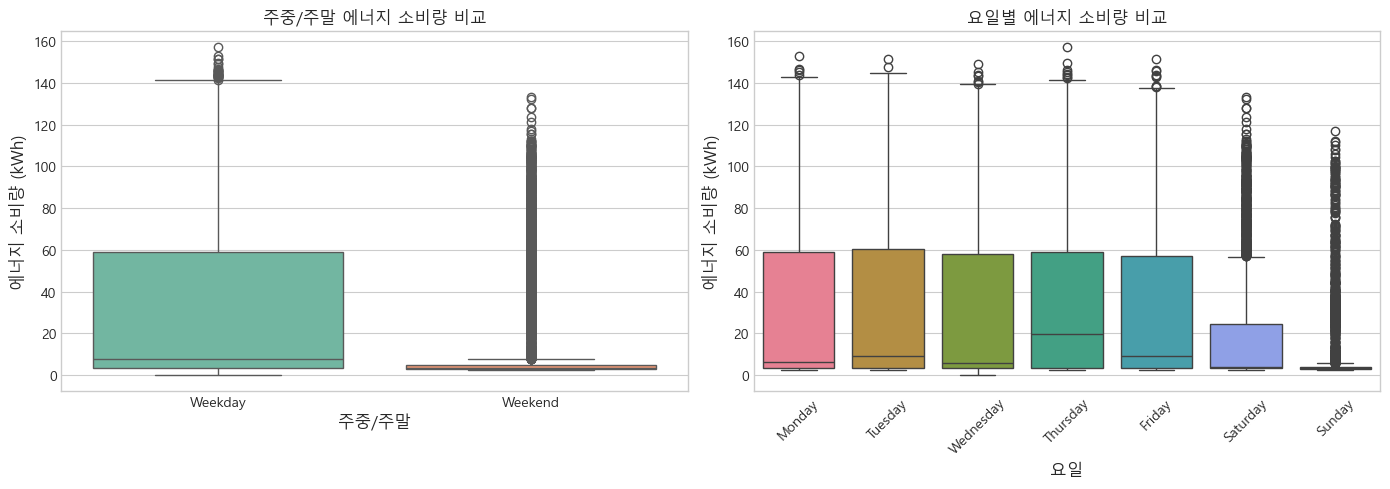

In [59]:
# 주중/주말별, 요일별 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 주중/주말
sns.boxplot(x='WeekStatus', y='Usage_kWh', data=df, ax=axes[0], palette='Set2')
axes[0].set_xlabel('주중/주말', fontsize=12)
axes[0].set_ylabel('에너지 소비량 (kWh)', fontsize=12)
axes[0].set_title('주중/주말 에너지 소비량 비교', fontsize=12)

# 요일별
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='Day_of_week', y='Usage_kWh', data=df, order=day_order, ax=axes[1], palette='husl')
axes[1].set_xlabel('요일', fontsize=12)
axes[1].set_ylabel('에너지 소비량 (kWh)', fontsize=12)
axes[1].set_title('요일별 에너지 소비량 비교', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**해석 예시:**
- 주중 vs 주말: 공장 가동률 차이에 따른 에너지 소비 패턴 확인
- 요일별: 월요일 시동 시 에너지 소비 증가, 금요일 오후 감소 등 운영 패턴 파악
- 주말 에너지 소비가 낮다면 → 주말 가동 축소 또는 정비 시간으로 해석 가능

### 4.3.4 바이올린 플롯(Violin Plot)

**바이올린 플롯(Violin Plot)** 은 상자그림과 KDE를 결합한 시각화로, 상자그림이 보여주지 못하는 **분포의 세부 형태(이봉성, 비대칭성 등)** 를 함께 표현함.

**사용 목적:**
- 상자그림만으로는 파악하기 어려운 분포의 형태를 확인할 때
- 이봉분포 여부를 판단할 때
- 분포의 밀도가 높은 영역을 시각적으로 확인할 때


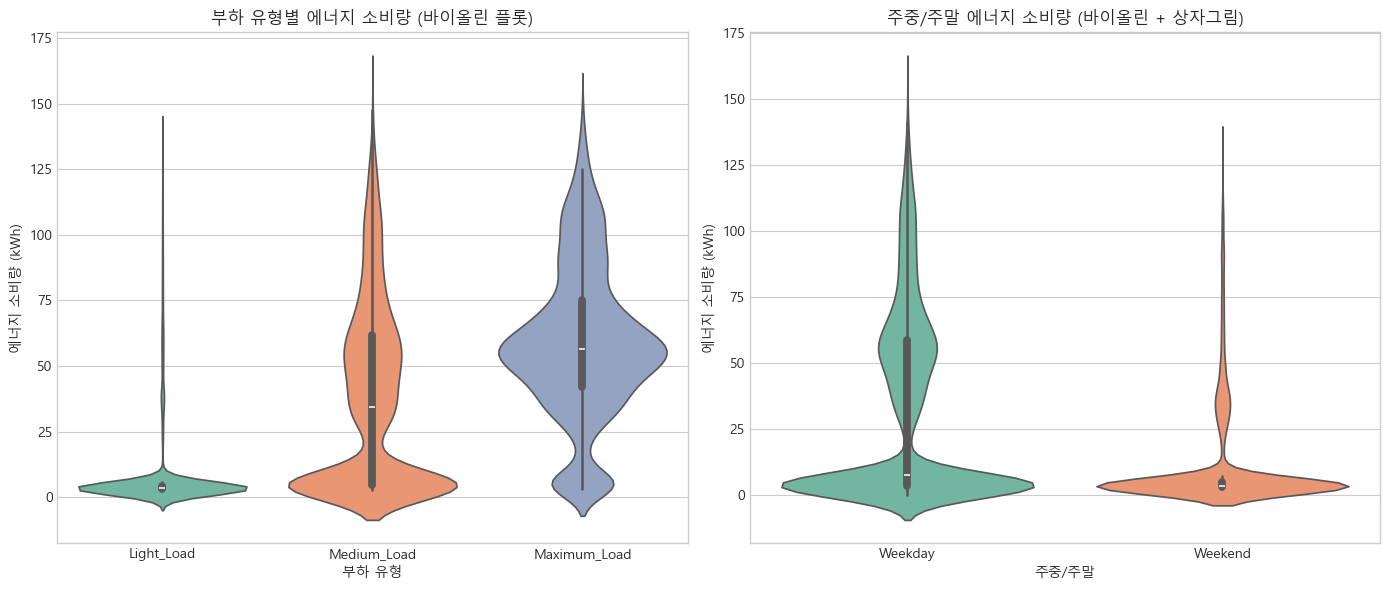

In [60]:
# 바이올린 플롯
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 부하 유형별
sns.violinplot(x='Load_Type', y='Usage_kWh', data=df, order=order, ax=axes[0], palette='Set2')
axes[0].set_title('부하 유형별 에너지 소비량 (바이올린 플롯)', fontsize=12)
axes[0].set_xlabel('부하 유형')
axes[0].set_ylabel('에너지 소비량 (kWh)')

# 상자그림과 바이올린 플롯 비교 (inner='box' 옵션)
sns.violinplot(x='WeekStatus', y='Usage_kWh', data=df, ax=axes[1], palette='Set2', inner='box')
axes[1].set_title('주중/주말 에너지 소비량 (바이올린 + 상자그림)', fontsize=12)
axes[1].set_xlabel('주중/주말')
axes[1].set_ylabel('에너지 소비량 (kWh)')

plt.tight_layout()
plt.show()

**바이올린 플롯 해석:**
- **바이올린의 너비**: 해당 값 근처의 데이터 밀도를 나타냄. 너비가 넓을수록 데이터가 많이 분포함
- **대칭성**: 바이올린이 좌우 대칭이면 분포도 대칭
- **다중 피크**: 바이올린에 여러 개의 볼록한 부분이 있으면 이봉분포 또는 다봉분포
- **`inner='box'` 옵션**: 바이올린 내부에 상자그림을 표시하여 사분위수와 중앙값을 함께 확인

**상자그림 vs 바이올린 플롯 선택 기준:**
- 그룹 수가 많거나 빠른 비교가 필요하면 → 상자그림
- 분포의 세부 형태가 중요하면 → 바이올린 플롯
- 보고서나 발표에서는 청중의 이해도에 따라 선택 (상자그림이 더 익숙한 경우가 많음)

## 4.4 산점도(Scatter Plot)

### 4.4.1 정의와 사용 목적

**산점도(Scatter Plot)** 는 두 연속형 변수 간의 **관계(relationship)** 를 점으로 표현한 그래프임. 각 데이터 포인트의 x좌표와 y좌표가 두 변수의 값을 나타냄.

**사용 목적:**
- 두 변수 간 **상관관계(correlation)** 여부 확인
- **선형/비선형 관계**의 패턴 파악
- **이상치** 탐지 (주 패턴에서 벗어난 점)
- **클러스터(군집)** 존재 여부 확인

**제조 현장 활용 예:**
- 온도 vs 불량률: 온도가 올라가면 불량률도 증가하는가?
- 에너지 소비량 vs CO2 배출량: 에너지 효율 평가
- 가동 시간 vs 생산량: 생산성 분석

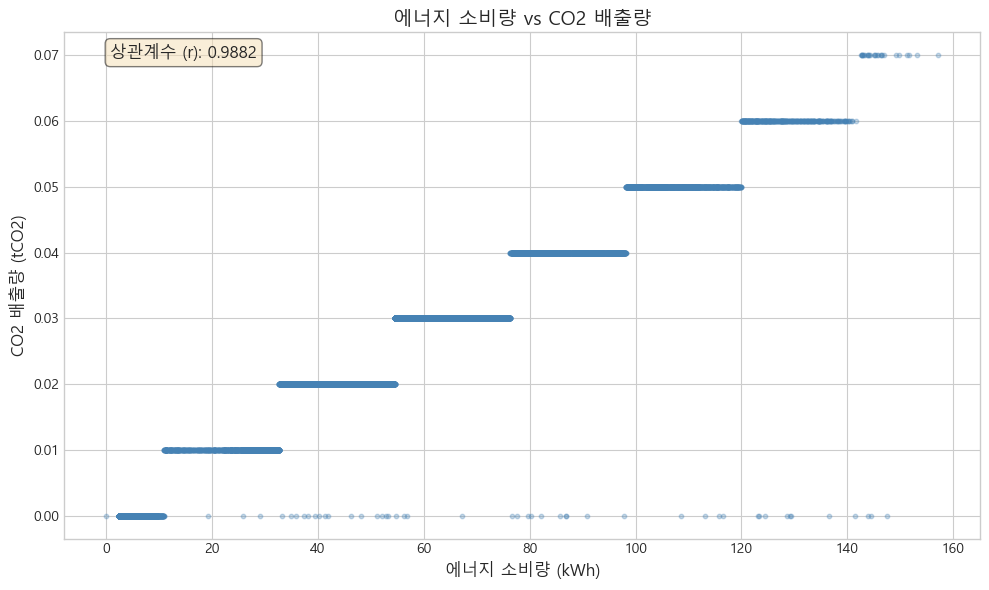

In [61]:
# CO2 배출량 vs 에너지 소비량
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['Usage_kWh'], df['CO2'], alpha=0.3, s=10, c='steelblue')
ax.set_xlabel('에너지 소비량 (kWh)', fontsize=12)
ax.set_ylabel('CO2 배출량 (tCO2)', fontsize=12)
ax.set_title('에너지 소비량 vs CO2 배출량', fontsize=14)

# 상관계수 표시
corr = df['Usage_kWh'].corr(df['CO2'])
ax.annotate(f'상관계수 (r): {corr:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**산점도 해석 방법:**
- **점들의 전반적인 방향**: 우상향(양의 관계), 우하향(음의 관계), 무작위(관계 없음)
- **점들의 밀집도**: 밀집되어 있으면 강한 관계, 흩어져 있으면 약한 관계
- **패턴의 형태**: 직선 패턴(선형), 곡선 패턴(비선형)
- **주 패턴에서 벗어난 점**: 이상치로 추가 조사 필요
- **alpha(투명도) 조절**: 데이터가 많을 때 점의 중첩을 시각화하기 위해 사용

### 상관관계의 종류와 해석

상관관계의 **강도와 방향**을 시각적으로 이해하기 위한 예시임. 상관계수 $r$의 범위는 $-1$에서 $+1$까지이며, 값에 따른 해석은 다음과 같음.

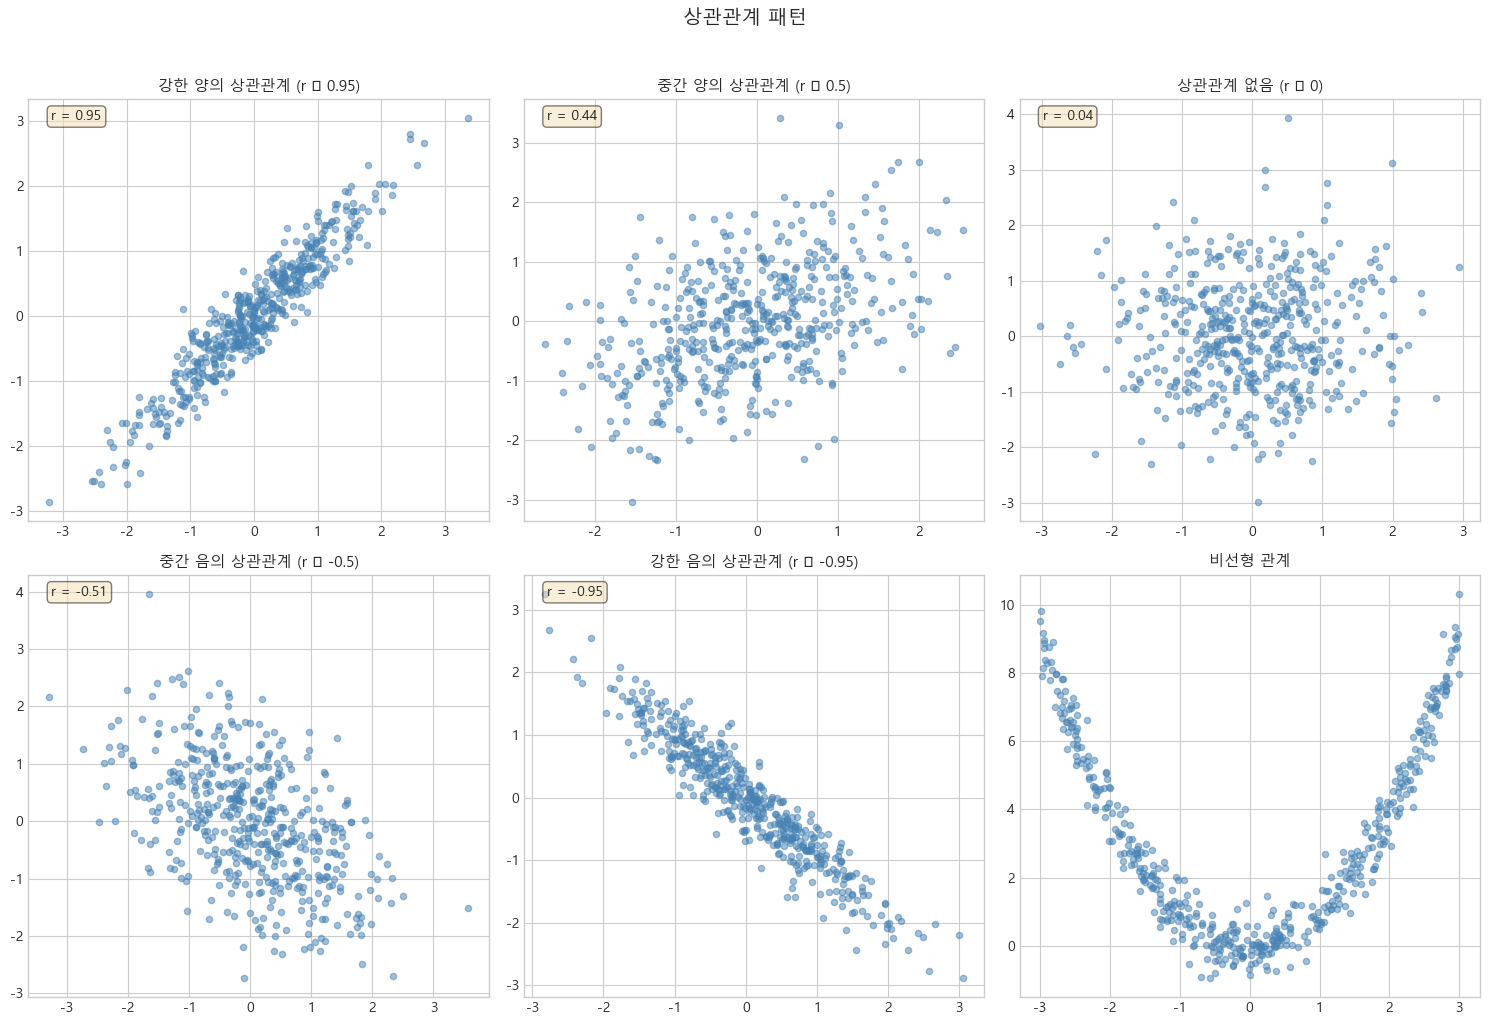

In [62]:
# 다양한 상관관계 패턴
np.random.seed(42)
n = 500

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

correlations = [
    (0.95, '강한 양의 상관관계 (r ≈ 0.95)'),
    (0.5, '중간 양의 상관관계 (r ≈ 0.5)'),
    (0, '상관관계 없음 (r ≈ 0)'),
    (-0.5, '중간 음의 상관관계 (r ≈ -0.5)'),
    (-0.95, '강한 음의 상관관계 (r ≈ -0.95)'),
    ('nonlinear', '비선형 관계')
]

for ax, (corr_val, title) in zip(axes.flatten(), correlations):
    if corr_val == 'nonlinear':
        x = np.random.uniform(-3, 3, n)
        y = x**2 + np.random.normal(0, 0.5, n)
    else:
        # Cholesky decomposition을 이용한 상관 데이터 생성
        mean = [0, 0]
        cov = [[1, corr_val], [corr_val, 1]]
        data = np.random.multivariate_normal(mean, cov, n)
        x, y = data[:, 0], data[:, 1]
    
    ax.scatter(x, y, alpha=0.5, s=20, c='steelblue')
    ax.set_title(title, fontsize=11)
    if corr_val != 'nonlinear':
        actual_corr = np.corrcoef(x, y)[0, 1]
        ax.annotate(f'r = {actual_corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('상관관계 패턴', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**피어슨 상관계수(Pearson Correlation Coefficient)** 는 두 변수 간의 **선형 관계의 강도와 방향**을 -1에서 +1 사이의 값으로 측정함.

**공식:**

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

이를 **공분산(Covariance)**과 **표준편차**로 표현하면:

$$r = \frac{Cov(X, Y)}{s_X \cdot s_Y}$$

여기서:
- $Cov(X, Y) = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{n-1}$: X와 Y의 공분산
- $s_X, s_Y$: 각 변수의 표준편차

**상관계수 해석 기준:**

| 상관계수 범위 | 해석 | 제조 현장 예시 |
|--------------|------|----------------|
| $0.9 \leq |r| \leq 1.0$ | 매우 강한 상관 | 에너지 소비량 ↔ CO2 배출량 (직접적 관계) |
| $0.7 \leq |r| < 0.9$ | 강한 상관 | 온도 ↔ 점도 (물리적 관계가 있는 변수) |
| $0.4 \leq |r| < 0.7$ | 중간 상관 | 습도 ↔ 불량률 (간접적 영향) |
| $0.2 \leq |r| < 0.4$ | 약한 상관 | 교대 시간 ↔ 품질 (약간의 연관성) |
| $|r| < 0.2$ | 상관 없음 | 로트 번호 ↔ 무게 (무관한 변수) |

**주의 사항:**
- **상관관계 ≠ 인과관계**: 두 변수가 상관이 있다고 해서 한 변수가 다른 변수를 *유발*한다는 의미는 아님
- **비선형 관계 주의**: 피어슨 상관계수는 **선형 관계만** 측정함. 위 그래프의 '비선형 관계' 예시에서 r ≈ 0이지만 명확한 관계가 존재함
- **이상치 영향**: 극단값 하나가 상관계수를 크게 왜곡할 수 있음


# 상관계수와 연관되는, 회귀와 관련된 부분은 7차시에 보다 구체적으로 다루겠음

In [66]:
#여러 변수 간의 상관관계를 한눈에 파악하려면 상관계수 행렬(Correlation Matrix)을 계산함. 행렬의 각 셀은 해당 행과 열 변수 간의 상관계수를 나타냄.

# 수치형 변수 선택
numeric_cols = ['Usage_kWh', 'Lagging_Reactive_Power', 'Leading_Reactive_Power', 
                'CO2', 'Lagging_Power_Factor', 'Leading_Power_Factor']

# 상관계수 행렬 계산
corr_matrix = df[numeric_cols].corr()

print("상관계수 행렬")
print("=" * 80)
print(corr_matrix.round(4))


상관계수 행렬
                        Usage_kWh  Lagging_Reactive_Power  \
Usage_kWh                  1.0000                  0.8961   
Lagging_Reactive_Power     0.8961                  1.0000   
Leading_Reactive_Power    -0.3249                 -0.4051   
CO2                        0.9882                  0.8869   
Lagging_Power_Factor       0.3860                  0.1445   
Leading_Power_Factor       0.3536                  0.4077   

                        Leading_Reactive_Power     CO2  Lagging_Power_Factor  \
Usage_kWh                              -0.3249  0.9882                0.3860   
Lagging_Reactive_Power                 -0.4051  0.8869                0.1445   
Leading_Reactive_Power                  1.0000 -0.3328                0.5268   
CO2                                    -0.3328  1.0000                0.3796   
Lagging_Power_Factor                    0.5268  0.3796                1.0000   
Leading_Power_Factor                   -0.9440  0.3600               -0.5200   

   

#### 히트맵(Heatmap)

**히트맵**은 상관계수 행렬을 **색상으로 시각화**하여 변수 간 관계를 직관적으로 파악할 수 있게 함.

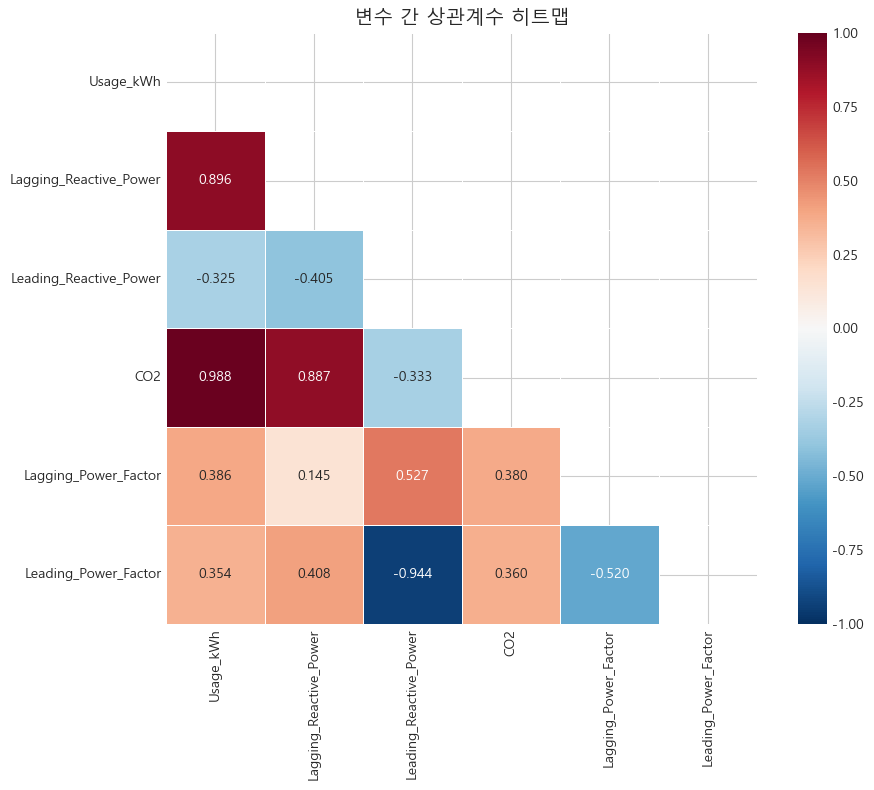

In [67]:
# 상관계수 히트맵
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스크 (중복 제거)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.3f', square=True, linewidths=0.5, ax=ax,
            mask=mask, vmin=-1, vmax=1)

ax.set_title('변수 간 상관계수 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

**히트맵 해석:**
- **색상 의미**: 빨간색(양의 상관), 파란색(음의 상관), 흰색(상관 없음)
- **색상 강도**: 진할수록 상관관계가 강함
- **`mask=mask`**: 상삼각 행렬을 가려서 중복 정보 제거
- **`center=0`**: 0을 중심으로 색상 스케일 설정

**활용 시나리오:**
- 변수가 많을 때 어떤 변수들이 서로 관련이 있는지 빠르게 파악
- 머신러닝 모델링 전 다중공선성(multicollinearity) 문제 탐지
- 품질에 영향을 미치는 핵심 변수 선별

## 4.6 시계열 패턴 시각화

### 4.6.1 시간별 패턴 분석

제조 데이터에서 **시간대별 패턴**을 파악하는 것은 에너지 관리, 생산 계획, 품질 관리에 중요한 인사이트를 제공함.

**분석 목적:**
- 피크 시간대 파악 → 전력 요금 최적화
- 저부하 시간대 파악 → 정비 일정 수립
- 비정상 패턴 탐지 → 공정 이상 조기 발견

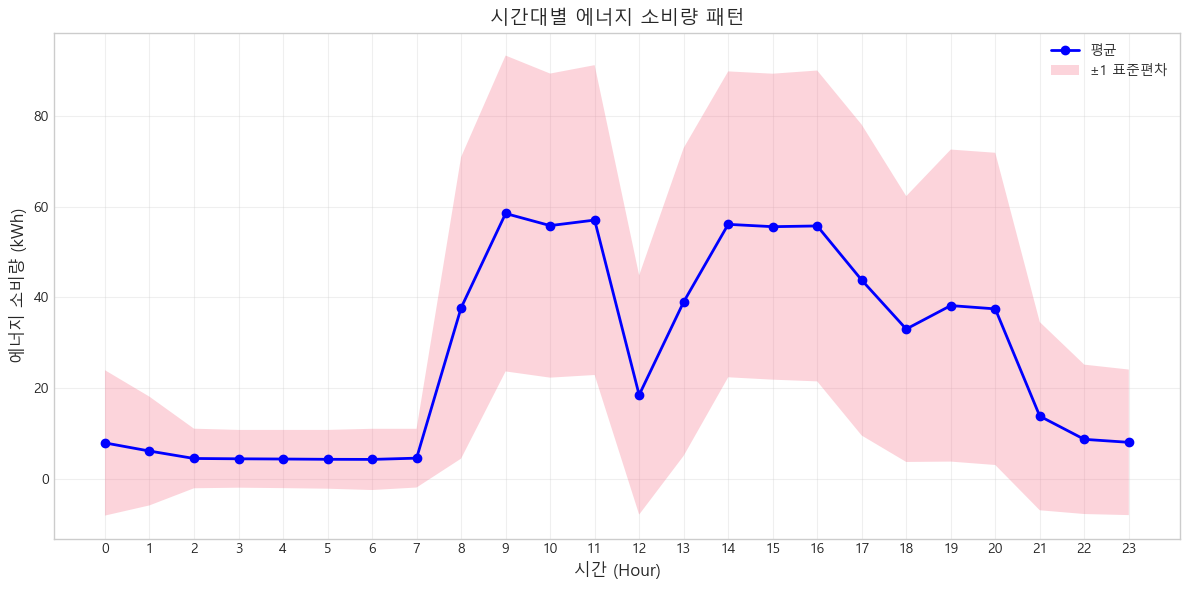

시간대별 에너지 소비량 패턴 해석:
--------------------------------------------------
• 새벽(0-6시): 상대적으로 낮은 소비량 → 야간 저부하 운전 또는 정비 시간
• 오전(6-9시): 급격한 증가 → 주간 가동 시작, 시동 에너지 소모
• 낮(9-18시): 피크 소비 시간대 → 본격적인 생산 활동
• 저녁(18-24시): 점진적 감소 → 야간 교대 또는 가동 축소

• 표준편차 범위: 해당 시간대의 소비량 변동성을 나타냄
  - 범위가 좁으면 → 안정적인 운전
  - 범위가 넓으면 → 변동이 큰 운전 (원인 분석 필요)


In [68]:
# NSM (자정부터 경과 시간)을 시간으로 변환
df['Hour'] = (df['NSM'] / 3600).astype(int)

# 시간별 평균 에너지 소비량
hourly_usage = df.groupby('Hour')['Usage_kWh'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(hourly_usage.index, hourly_usage['mean'], 'b-', linewidth=2, marker='o', label='평균')
ax.fill_between(hourly_usage.index, 
                hourly_usage['mean'] - hourly_usage['std'],
                hourly_usage['mean'] + hourly_usage['std'],
                alpha=0.3, label='±1 표준편차')

ax.set_xlabel('시간 (Hour)', fontsize=12)
ax.set_ylabel('에너지 소비량 (kWh)', fontsize=12)
ax.set_title('시간대별 에너지 소비량 패턴', fontsize=14)
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("시간대별 에너지 소비량 패턴 해석:")
print("-" * 50)
print("• 새벽(0-6시): 상대적으로 낮은 소비량 → 야간 저부하 운전 또는 정비 시간")
print("• 오전(6-9시): 급격한 증가 → 주간 가동 시작, 시동 에너지 소모")
print("• 낮(9-18시): 피크 소비 시간대 → 본격적인 생산 활동")
print("• 저녁(18-24시): 점진적 감소 → 야간 교대 또는 가동 축소")
print("\n• 표준편차 범위: 해당 시간대의 소비량 변동성을 나타냄")
print("  - 범위가 좁으면 → 안정적인 운전")
print("  - 범위가 넓으면 → 변동이 큰 운전 (원인 분석 필요)")

### 4.6.2 요일 × 시간 복합 패턴

**히트맵**을 활용하면 요일과 시간의 **2차원 패턴**을 한눈에 파악할 수 있음.

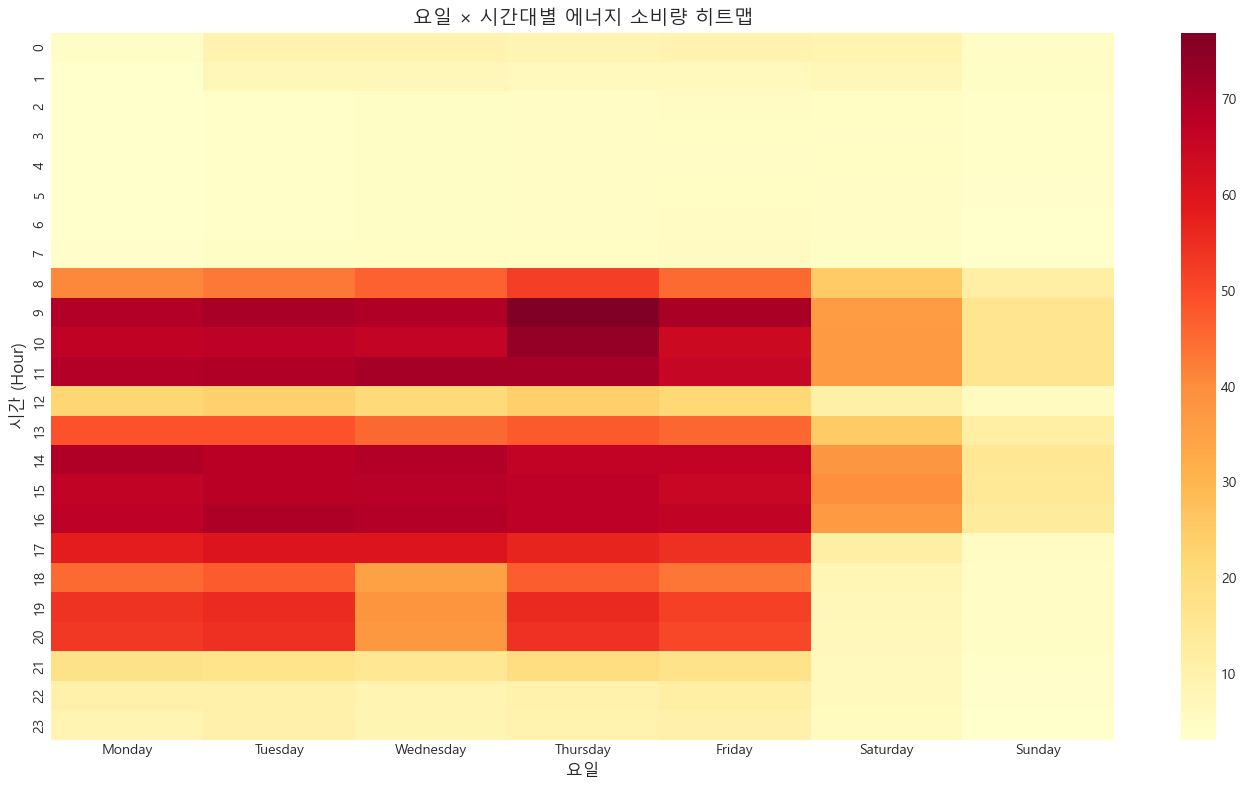

In [70]:
# 요일별, 시간별 평균 에너지 소비량
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_data = df.pivot_table(values='Usage_kWh', index='Hour', columns='Day_of_week', aggfunc='mean')
pivot_data = pivot_data[day_order]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, ax=ax)
ax.set_xlabel('요일', fontsize=12)
ax.set_ylabel('시간 (Hour)', fontsize=12)
ax.set_title('요일 × 시간대별 에너지 소비량 히트맵', fontsize=14)

plt.tight_layout()
plt.show()


**히트맵 해석:**
- **색상이 진한 영역**: 에너지 소비량이 높은 시간대/요일
- **색상이 옅은 영역**: 에너지 소비량이 낮은 시간대/요일
- **주중 vs 주말 패턴 차이**: 주말에 전반적으로 옅으면 주말 가동 축소
- **특정 요일의 이상 패턴**: 정기 정비일, 특수 작업일 등 확인

**실무 활용:**
- 전력 피크 요금 시간대와 실제 피크 소비 시간대 비교 -> 비용 최적화
- 주말 가동 여부에 따른 에너지 전략 수립
- 야간 교대 근무의 에너지 효율 분석

## 4.7 종합 대시보드

EDA 결과를 **하나의 대시보드**로 구성하면 데이터의 전반적인 특성을 한눈에 파악할 수 있음. 이 대시보드는 보고서나 발표 자료로 활용하기에도 적합함.


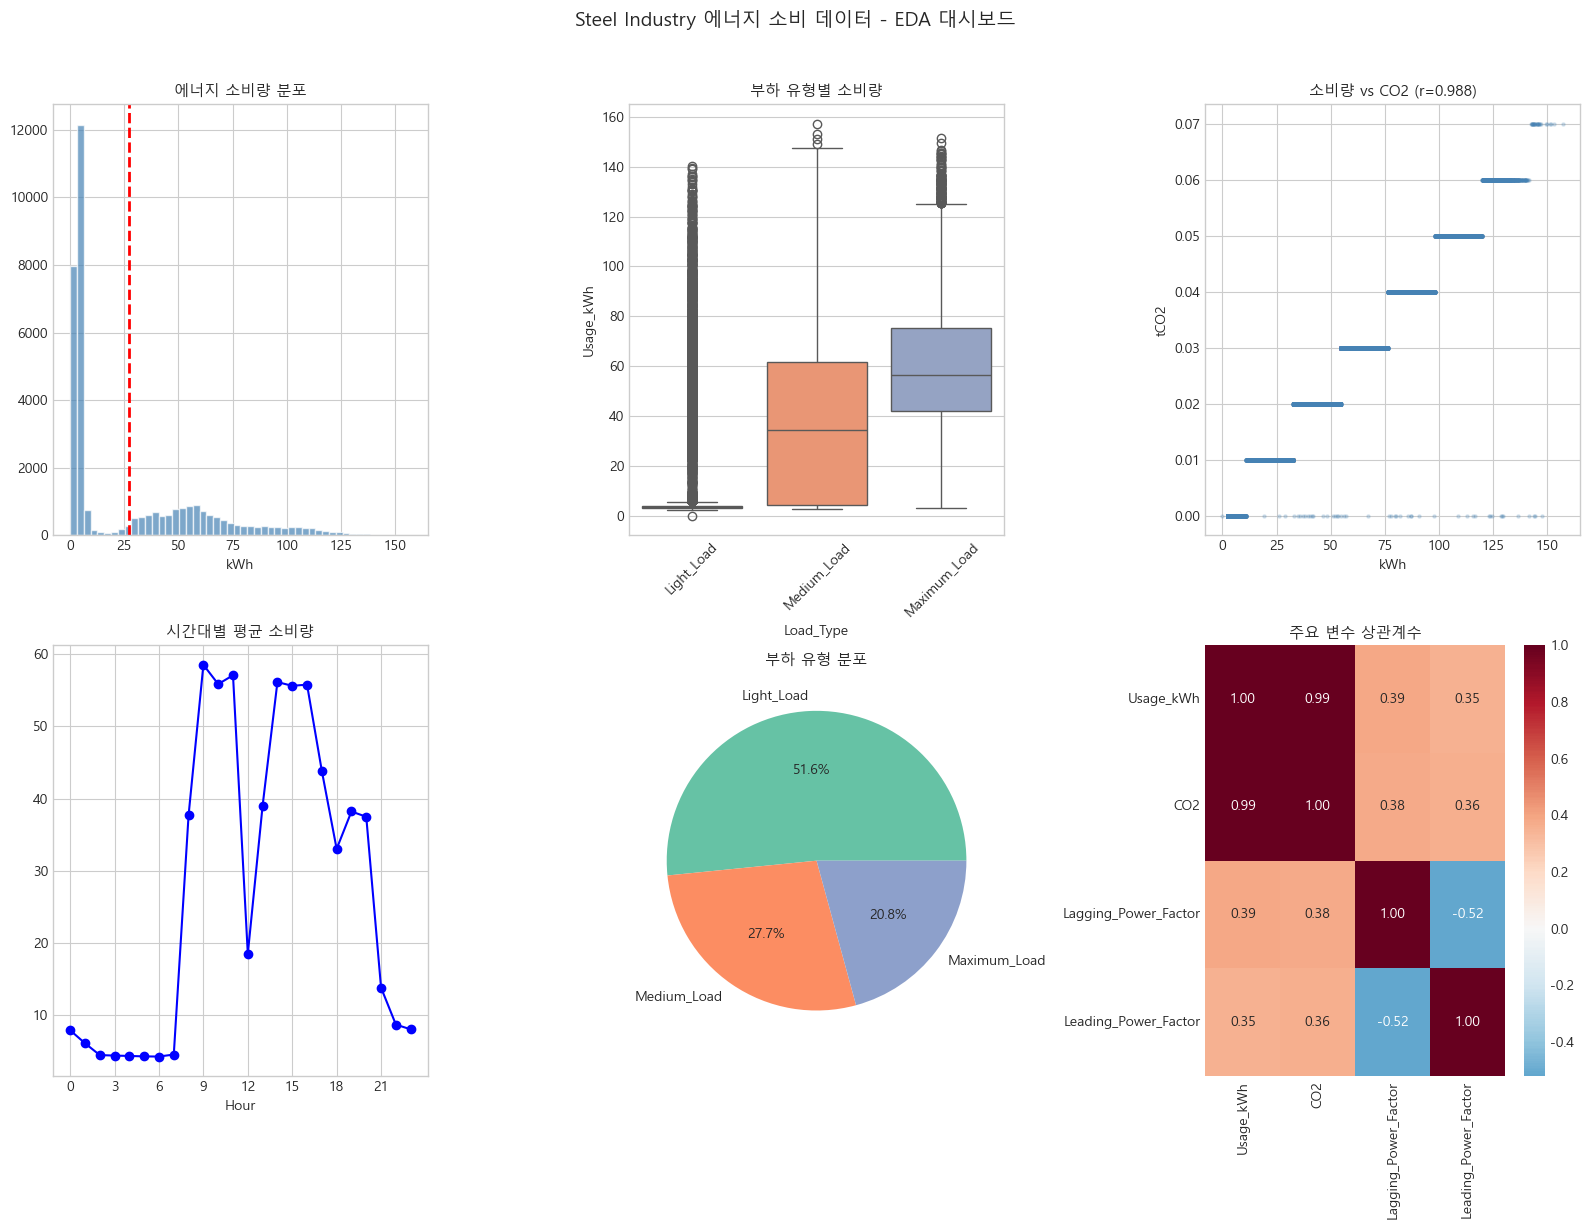

In [71]:
# 종합 EDA 대시보드
fig = plt.figure(figsize=(16, 12))

# 1. 히스토그램: 전체 분포 확인
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(df['Usage_kWh'], bins=50, edgecolor='white', alpha=0.7, color='steelblue')
ax1.axvline(df['Usage_kWh'].mean(), color='red', linestyle='--', linewidth=2)
ax1.set_title('에너지 소비량 분포', fontsize=11)
ax1.set_xlabel('kWh')

# 2. 상자그림: 그룹별 비교
ax2 = fig.add_subplot(2, 3, 2)
sns.boxplot(x='Load_Type', y='Usage_kWh', data=df, ax=ax2, palette='Set2', order=order)
ax2.set_title('부하 유형별 소비량', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

# 3. 산점도: 변수 간 관계
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(df['Usage_kWh'], df['CO2'], alpha=0.2, s=5, c='steelblue')
ax3.set_title(f'소비량 vs CO2 (r={df["Usage_kWh"].corr(df["CO2"]):.3f})', fontsize=11)
ax3.set_xlabel('kWh')
ax3.set_ylabel('tCO2')

# 4. 시계열: 시간별 패턴
ax4 = fig.add_subplot(2, 3, 4)
hourly_mean = df.groupby('Hour')['Usage_kWh'].mean()
ax4.plot(hourly_mean.index, hourly_mean.values, 'b-', marker='o')
ax4.set_title('시간대별 평균 소비량', fontsize=11)
ax4.set_xlabel('Hour')
ax4.set_xticks(range(0, 24, 3))

# 5. 파이차트: 범주 비율
ax5 = fig.add_subplot(2, 3, 5)
load_counts = df['Load_Type'].value_counts()
ax5.pie(load_counts.values, labels=load_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
ax5.set_title('부하 유형 분포', fontsize=11)

# 6. 상관계수 히트맵: 변수 간 관계 요약
ax6 = fig.add_subplot(2, 3, 6)
corr_subset = df[['Usage_kWh', 'CO2', 'Lagging_Power_Factor', 'Leading_Power_Factor']].corr()
sns.heatmap(corr_subset, annot=True, cmap='RdBu_r', center=0, ax=ax6, fmt='.2f')
ax6.set_title('주요 변수 상관계수', fontsize=11)

plt.suptitle('Steel Industry 에너지 소비 데이터 - EDA 대시보드', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

| 패널 | 질문 | 확인 포인트 |
|------|------|------------|
| 1. 히스토그램 | 데이터 분포가 어떤 형태인가? | 정규성, 비대칭성, 이상치 |
| 2. 상자그림 | 그룹 간 차이가 있는가? | 중앙값 위치, IQR 크기, 이상치 |
| 3. 산점도 | 주요 변수 간 관계는? | 상관 방향, 강도, 비선형성 |
| 4. 시계열 | 시간에 따른 패턴이 있는가? | 피크 시간, 주기성 |
| 5. 파이차트 | 범주별 비율은 어떠한가? | 데이터 구성 비율 |
| 6. 히트맵 | 어떤 변수들이 서로 관련 있는가? | 강한 상관 쌍, 다중공선성 |


# 핵심 요약

## 대표값(Central Tendency)

**핵심 개념:** 대표값은 데이터의 중심 위치를 하나의 숫자로 요약함.

| 측도 | 수식 | 특징 | 적용 상황 |
|------|------|------|----------|
| **평균** | $\bar{x} = \frac{\sum x_i}{n}$ | 모든 값 반영, 이상치에 민감 | 정규분포, 이상치 없음 |
| **중앙값** | 정렬 후 중앙 위치 | 극단값에 강건 | 비대칭 분포, 이상치 존재 |
| **최빈값** | 가장 빈번한 값 | 여러 개 가능 | 범주형 데이터 |

**실무 팁:** 평균과 중앙값의 차이가 크면 이상치나 비대칭 분포를 의심해야 함.

## 산포도(Dispersion)

**핵심 개념:** 산포도는 데이터가 중심에서 얼마나 퍼져 있는지를 측정함.

| 측도 | 수식 | 특징 | 활용 |
|------|------|------|------|
| **범위** | $R = X_{max} - X_{min}$ | 극단값만 사용, 이상치에 민감 | 빠른 개략 파악 |
| **분산** | $s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1}$ | 단위가 제곱됨 | 수학적 계산에 활용 |
| **표준편차** | $s = \sqrt{s^2}$ | 원래 단위 유지, 해석 용이 | 품질 관리, 관리도 |
| **IQR** | $Q3 - Q1$ | 이상치에 강건 | 이상치 탐지 기준 |

**실무 팁:** 표준편차는 "평균에서 대략 이 정도 떨어져 있다"로 해석. IQR은 이상치 탐지에 사용.

## 시각화

**핵심 원칙:** 분석 목적에 맞는 시각화를 선택해야 함.

| 분석 목적 | 권장 시각화 | 확인 포인트 |
|----------|------------|------------|
| 단일 변수 분포 | 히스토그램, KDE | 중심, 퍼짐, 대칭성, 이상치 |
| 그룹 간 비교 | 상자그림, 바이올린 플롯 | 중앙값 차이, 변동성 비교 |
| 두 변수 관계 | 산점도 (+ 회귀선) | 상관 방향, 강도, 선형성 |
| 다변량 관계 | 히트맵, 페어플롯 | 변수 쌍별 상관, 다중공선성 |
| 시계열 패턴 | 라인 그래프, 2D 히트맵 | 시간별 추세, 주기성 |